In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 

from univariate_analysis import histogram_by_class, boxplot_by_class, bar_chart, pie_chart

In [2]:
%load_ext autoreload
%autoreload 2

# Bureau Data Analysis.

To create the behavioural scorecard, there is a need to investigate the performance of each consumer over the last 12 months before the time of application, and then assess their performance over a later window to evaluate the scorecard (https://www.finalyse.com/blog/banking/behavioral-scorecard-with-machine-learning-components)

We start by analysing the bureau data for all transactions within the last 12 months relative to the time of application. This is done by selecting entries WHERE `DAYS_CREDIT_AMOUNT` > 0 and `DAYS_ENDDATE_FACT` > -365. 

In [3]:
bureau_df = pd.read_csv("home_credit/bureau.csv")


In [32]:
"""Column-level analysis of a dataset.

Produces, for every column:
  1. Variable types   - pandas dtype, an inferred semantic type, and cardinality.
  2. Missing values   - count and percentage of nulls (blank/whitespace strings
                        and common null placeholders are treated as missing).
  3. Summary          - describe() for numeric/datetime columns, value counts and
                        top categories for object/categorical columns.

Requires the `data_science` conda environment (pandas 3.0.3, numpy 2.5.1):

    conda activate data_science
    python credit_risk/loan_column_analysis.py

Without activating, call the environment's interpreter directly:

    ~/anaconda3/envs/data_science/python.exe credit_risk/loan_column_analysis.py

To analyse a different file or a row-capped sample, edit DATA_PATH / SAMPLE below.
"""

from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

#DATA_PATH = Path(__file__).resolve().parent / "home_credit" / "bureau.csv"
#SAMPLE = None  # int to read only the first N rows, None for the full file

# # Strings that mean "no value" but are not read as NaN by default.
# NULL_TOKENS = {"", "na", "n/a", "nan", "null", "none", "-", "?", "unknown", "missing"}

# A column with few distinct values relative to its length is treated as
# categorical even when stored as text or as an integer-valued float.
CATEGORICAL_MAX_UNIQUE = 50
CATEGORICAL_MAX_RATIO = 0.05

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)


def load(path: Path, sample: int | None) -> pd.DataFrame:
    """Read the CSV, letting pandas infer dtypes, with an optional row cap."""
    df = pd.read_csv(path, nrows=sample, low_memory=False)
    # Parse the date-ish columns so they summarise as dates rather than strings.
    for col, fmt in (("issue_d", "%b-%y"), ("issue_date", "%B %Y")):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format=fmt, errors="coerce")
    return df


# def normalise_missing(df: pd.DataFrame) -> pd.DataFrame:
#     """Turn placeholder strings ('', ' ', 'N/A', ...) into real NaNs."""
#     out = df.copy()
#     for col in out.columns:
#         if out[col].dtype == object:
#             stripped = out[col].astype("string").str.strip()
#             out[col] = stripped.mask(stripped.str.lower().isin(NULL_TOKENS))
#     return out


def infer_semantic_type(s: pd.Series) -> str:
    """Label a column beyond its raw dtype: id / binary / categorical / ..."""
    non_null = s.dropna()
    if non_null.empty:
        return "empty"

    n_unique = non_null.nunique()
    ratio = n_unique / len(non_null)

    if pd.api.types.is_datetime64_any_dtype(s):
        return "datetime"
    if pd.api.types.is_bool_dtype(s) or n_unique == 2:
        return "binary"
    if n_unique == 1:
        return "constant"
    if pd.api.types.is_numeric_dtype(s):
        is_whole = bool((non_null % 1 == 0).all())
        # Near-unique integers are almost always identifiers, not measurements.
        if ratio > 0.99 and is_whole:
            return "identifier (numeric)"
        if is_whole:
            if n_unique <= CATEGORICAL_MAX_UNIQUE:
                return "categorical (integer-coded)"
            return "numeric (discrete)"
        return "numeric (continuous)"
    if ratio > 0.99:
        return "identifier (text)"
    if n_unique <= CATEGORICAL_MAX_UNIQUE or ratio <= CATEGORICAL_MAX_RATIO:
        return "categorical"
    return "text / high-cardinality"


def type_table(df: pd.DataFrame) -> pd.DataFrame:
    """Section 1: dtype, inferred type, cardinality and an example value."""
    rows = []
    for col in df.columns:
        s = df[col]
        non_null = s.dropna()
        rows.append(
            {
                "column": col,
                "dtype": str(s.dtype),
                "inferred_type": infer_semantic_type(s),
                "n_unique": int(non_null.nunique()),
                "unique_ratio": round(non_null.nunique() / len(s), 4) if len(s) else np.nan,
                "example": (str(non_null.iloc[0])[:40] if not non_null.empty else ""),
                "memory_mb": round(s.memory_usage(deep=True) / 1024**2, 2),
            }
        )
    return pd.DataFrame(rows).set_index("column")


def missing_table(raw: pd.DataFrame, clean: pd.DataFrame) -> pd.DataFrame:
    """Section 2: nulls per column, split into true NaNs and placeholders."""
    n = len(clean)
    rows = []
    for col in clean.columns:
        native = int(raw[col].isna().sum())
        total = int(clean[col].isna().sum())
        rows.append(
            {
                "column": col,
                "n_missing": total,
                "pct_missing": round(100 * total / n, 2) if n else np.nan,
                "n_native_nan": native,
                "n_placeholder": total - native,  # '', 'N/A', 'unknown', ...
                "n_present": n - total,
                "complete": total == 0,
            }
        )
    return pd.DataFrame(rows).set_index("column").sort_values("pct_missing", ascending=False)


def summarise_numerical_column(s: pd.Series) -> None:
    """Print describe() plus skew/kurtosis for a numerical column."""
    non_null = s.dropna()
    desc = non_null.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    print(desc.to_string())
    print(f"  skew={non_null.skew():.3f}  kurtosis={non_null.kurtosis():.3f}  "
          f"zeros={int((non_null == 0).sum())}  negatives={int((non_null < 0).sum())}")


def summarise_categorical_column(s: pd.Series) -> None:
    """Print value counts and top categories for a categorical column, keeping NaN as its own category."""
    counts = s.value_counts(dropna=False)
    print(f"  n_unique={counts.size}")
    print("  top values:")
    top = counts.head(15)
    pct = (100 * top / len(s)).round(2)
    print(pd.DataFrame({"count": top, "pct_of_rows": pct}).to_string())
    if counts.size > 15:
        print(f"  ... {counts.size - 15} further categories")


def summarise_datetime_column(s: pd.Series) -> None:
    """Print describe() and a by-year breakdown for a datetime column."""
    non_null = s.dropna()
    print(non_null.describe().to_string())
    print("  by year:")
    print(non_null.dt.year.value_counts().sort_index().to_string())


def summarise_column(s: pd.Series, name: str) -> None:
    """Section 3: dispatch to the summary appropriate to the column's type."""
    kind = infer_semantic_type(s)
    print(f"\n--- {name}  [dtype={s.dtype}, inferred={kind}] ---")

    non_null = s.dropna()
    if non_null.empty:
        print("  (all values missing)")
        return

    if pd.api.types.is_numeric_dtype(s) and kind not in {"binary", "categorical (integer-coded)"}:
        summarise_numerical_column(s)
    elif pd.api.types.is_datetime64_any_dtype(s):
        summarise_datetime_column(s)
    else:
        summarise_categorical_column(s)


def main() -> None:
    raw = bureau_df
    df = bureau_df
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"Fully duplicated rows: {int(df.duplicated().sum()):,}")

    print("\n" + "=" * 100)
    print("1. VARIABLE TYPES")
    print("=" * 100)
    print(type_table(df).to_string())

    print("\n" + "=" * 100)
    print("2. MISSING VALUE ANALYSIS")
    print("=" * 100)
    miss = missing_table(raw, df)
    print(miss.to_string())
    incomplete = miss[~miss["complete"]]
    print(f"\nColumns with missing data: {len(incomplete)} of {df.shape[1]}")
    print(f"Rows with at least one missing value: {int(df.isna().any(axis=1).sum()):,} "
          f"({100 * df.isna().any(axis=1).mean():.2f}%)")
    print(f"Complete rows: {int((~df.isna().any(axis=1)).sum()):,}")

    print("\n" + "=" * 100)
    print("3. PER-COLUMN SUMMARY")
    print("=" * 100)
    numerical_cols, datetime_cols, categorical_cols = [], [], []
    for col in df.columns:
        s = df[col]
        kind = infer_semantic_type(s)
        if pd.api.types.is_numeric_dtype(s) and kind not in {"binary", "categorical (integer-coded)"}:
            numerical_cols.append(col)
        elif pd.api.types.is_datetime64_any_dtype(s):
            datetime_cols.append(col)
        else:
            categorical_cols.append(col)

    for label, cols in (
        ("Numerical columns", numerical_cols),
        ("Datetime columns", datetime_cols),
        ("Categorical columns", categorical_cols),
    ):
        print(f"\n--- {label} ---")
        for col in cols:
            summarise_column(df[col], col)

    print("\n" + "=" * 100)
    print("Numeric columns, describe() side by side")
    print("=" * 100)
    num = df.select_dtypes(include=[np.number])
    if not num.empty:
        print(num.describe().T.to_string())


if __name__ == "__main__":
    main()




Shape: 862,821 rows x 17 columns
Memory: 243.7 MB
Fully duplicated rows: 0

1. VARIABLE TYPES
                          dtype                inferred_type  n_unique  unique_ratio          example  memory_mb
column                                                                                                          
SK_ID_CURR                int64           numeric (discrete)    272654        0.3160           215354      13.17
SK_ID_BUREAU              int64         identifier (numeric)    862821        1.0000          5714462      13.17
CREDIT_ACTIVE               str                  categorical         3        0.0000           Closed      51.84
CREDIT_CURRENCY             str                  categorical         4        0.0000       currency 1      55.13
DAYS_CREDIT               int64           numeric (discrete)      2923        0.0034             -497      13.17
CREDIT_DAY_OVERDUE        int64           numeric (discrete)       836        0.0010                0      13.17
DA

A few things can be noted from the analysis. 

1. There is a "DAYS_CREDIT_UPDATE" column that reflects how recent the information about the loan is. In the case that the `DAYS_CREDIT_UPDATE` column is not recent, we will __assume that we can extrapolate the behaviour from the last update to the current day__ - i.e. if the customer did not default since the previous update, we will assume the customer did not default between the last update and the reference point. 
3. Annuity has a large number of missing values. The column will probably be dropped.

## Feature Engineering

From the dataset we would like to create the following features:
1. For each customer, number of late payments over the past 12 months. 
2. The longest late payment for each customer, if any. 

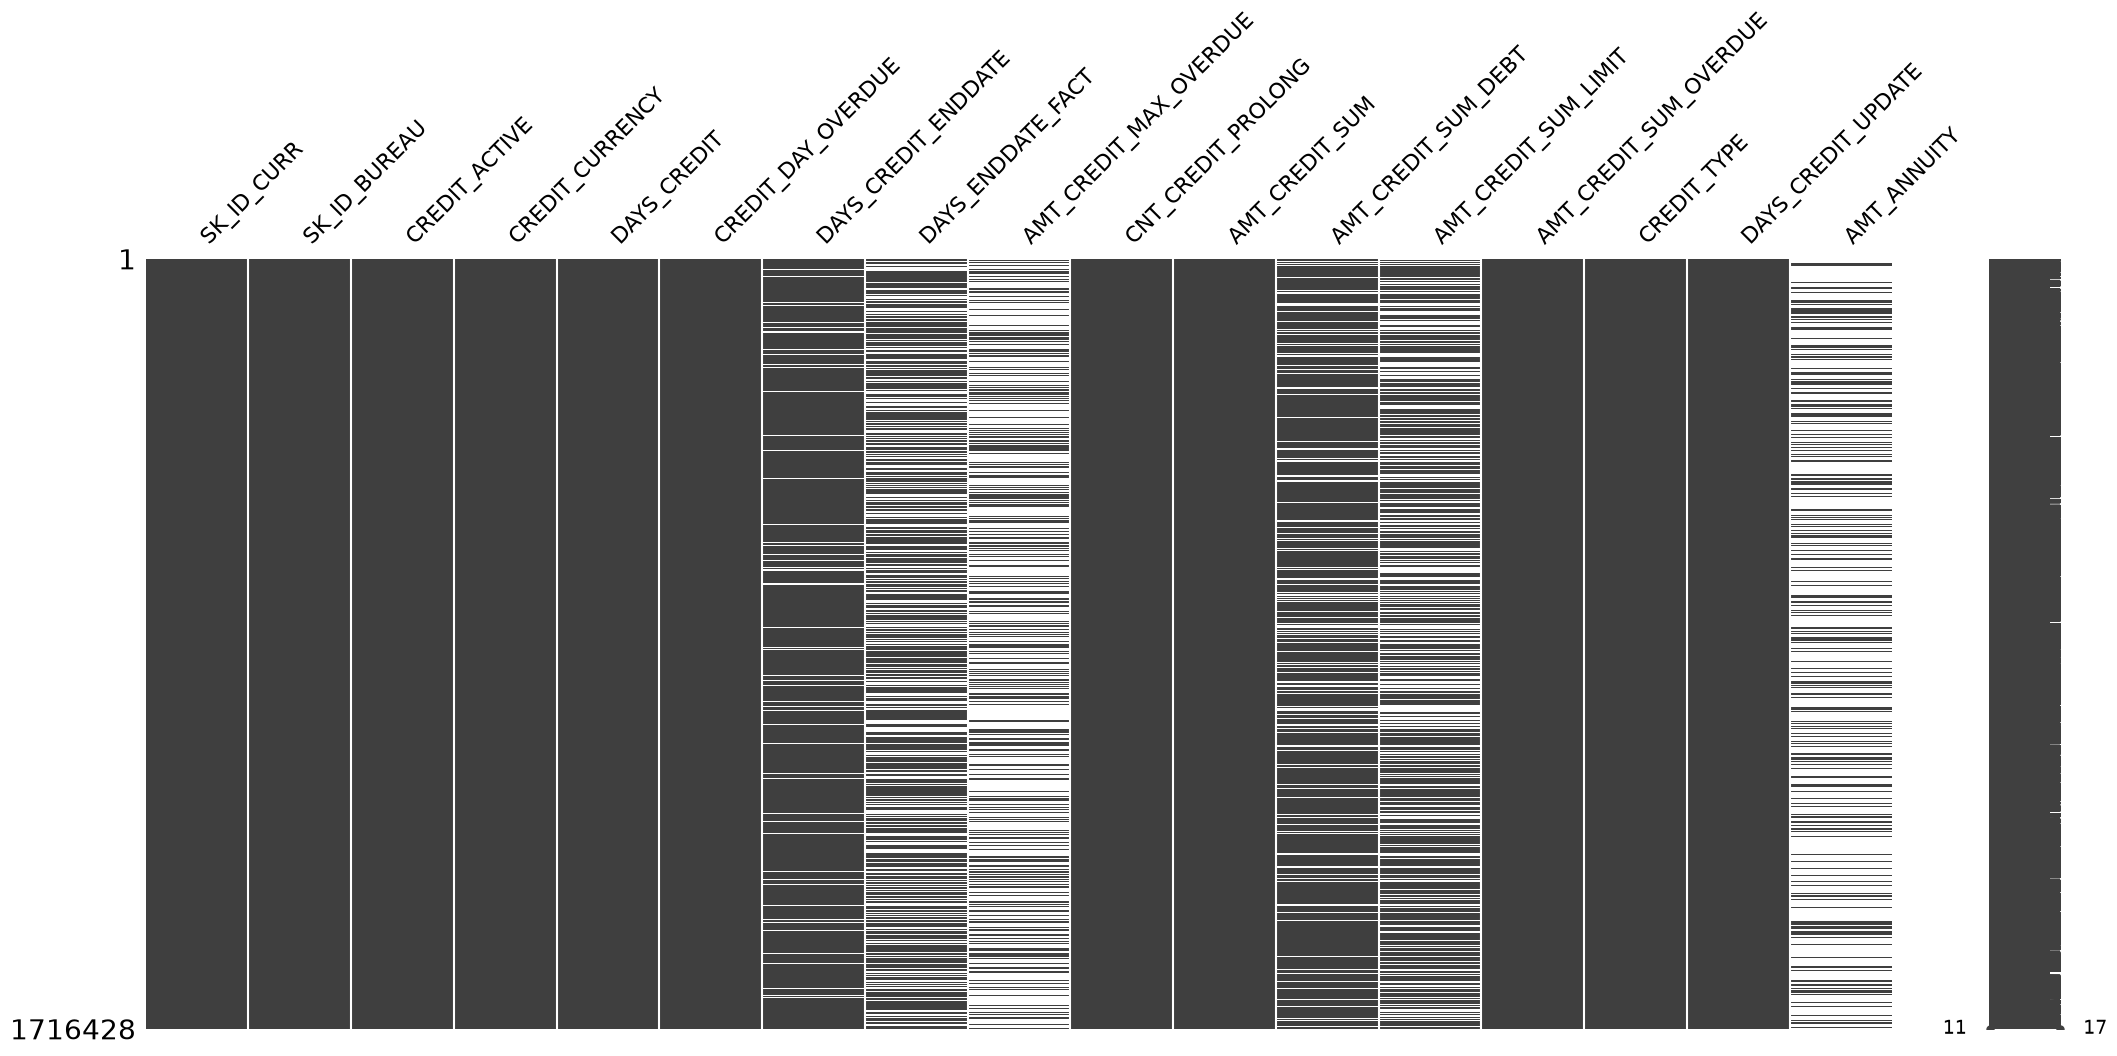

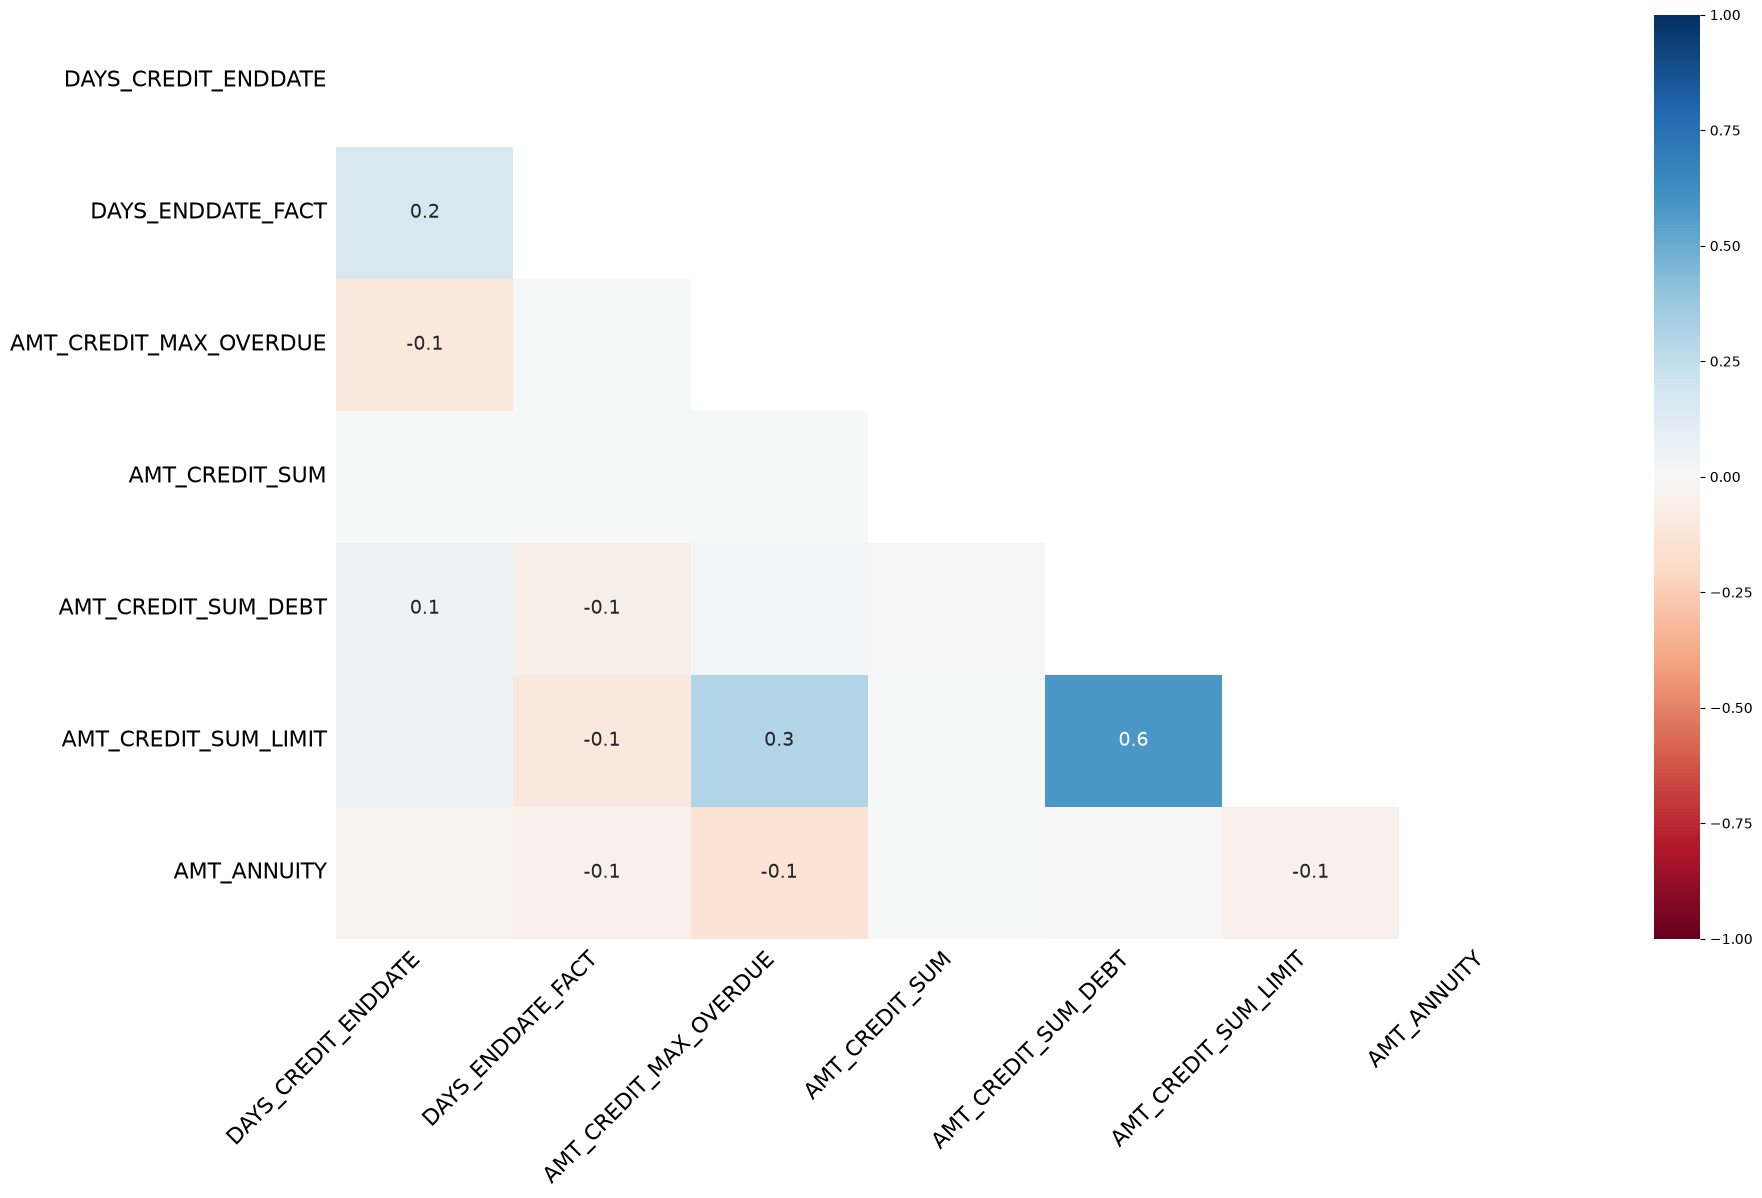

In [5]:
import missingno as msno

# Missing-value pattern across the full, unfiltered bureau.csv (no
# CREDIT_ACTIVE/DAYS_ENDDATE_FACT filtering applied here) before deciding how
# to handle nulls in any utilisation feature.
bureau_raw = pd.read_csv("home_credit/bureau.csv")
msno.matrix(bureau_raw)
plt.show()

# Nullity correlation: whether missingness in one column tends to co-occur
# with missingness in another, to spot columns that go missing together.
msno.heatmap(bureau_raw)
plt.show()

## Analysis of the Data - Switching to Active Data

An analysis from Claude revealed that for columns with non-NaN `AMT_CREDIT_SUM_DEBT`:
1. Non-revolving loans mostly have `CREDIT_SUM` > `AMT_CREDIT_SUM_DEBT`, which somewhat verifies the hypothesis that `CREDIT_SUM` is the original principal amount and `DEBT` is the outstanding balance.
2. For credit card loans the situation was mostly the same, but there was a large number of `AMT_CREDIT_SUM_DEBT` == 0 columns, with some exceeding `CREDIT_SUM`. 

However what remains to be checked is the nature of the missing values. A naive hypothesis is that the missing values are correlated with some of the columns, especially with `END_DATE` and `ENDDATE_FACT`, or could potentially be correlated with the `CREDIT_TYPE`, `CURRENCY` and `ACTIVE` . 

Another analysis from Claude Code reveals that missing values in `AMT_CREDIT_SUM_DEBT` is most missing where `CREDIT_STATUS` is "Sold". Because there is currently a lack of understanding of what "Sold" means, it becomes difficult to try to extract information from these columns, especially when we are trying to build a debt utilisation feature, where `AMT_CREDIT_SUM_DEBT` is included in the calculations and should not be NaN. Henceforth we will only restrict to "Active" entries. 

In [4]:
active = bureau_df[bureau_df["CREDIT_ACTIVE"] == "Active"]

In [18]:
#from column_analysis import basic_data_summary
from column_analysis import TypeTable, MissingValueTable, NumericalSummaryTable, CategoricalSummaryTable

# Basic summary 
#basic_data_summary(active)

# Type table 
print("\n" + "=" * 100)
print("1. VARIABLE TYPES")
print("=" * 100)
type_table = TypeTable()
print(type_table.plot_table(active).to_string())


# Missing table
print("\n" + "=" * 100)
print("2. MISSING VALUE ANALYSIS")
print("=" * 100)
missing_table = MissingValueTable()
print(missing_table.plot_table(active).to_string())

print("\n" + "=" * 100)
print("3a. NUMERICAL SUMMARY")
print("=" * 100)
numerical_table = NumericalSummaryTable()
print(numerical_table.plot_table(active).to_string())

print("\n" + "=" * 100)
print("3b. CATEGORICAL SUMMARY")
print("=" * 100)
cat_table = CategoricalSummaryTable()
print(cat_table.plot_table(active).to_string())


1. VARIABLE TYPES
                          dtype                inferred_type  n_unique  unique_ratio      example  memory_mb
column                                                                                                      
SK_ID_CURR                int64           numeric (discrete)    251815        0.3993       215354       9.62
SK_ID_BUREAU              int64         identifier (numeric)    630607        1.0000      5714463       9.62
CREDIT_ACTIVE               str                     constant         1        0.0000       Active      37.89
CREDIT_CURRENCY             str                  categorical         4        0.0000   currency 1      40.29
DAYS_CREDIT               int64           numeric (discrete)      2923        0.0046         -208       9.62
CREDIT_DAY_OVERDUE        int64           numeric (discrete)       825        0.0013            0       9.62
DAYS_CREDIT_ENDDATE     float64           numeric (discrete)     13450        0.0213       1075.0       9.62


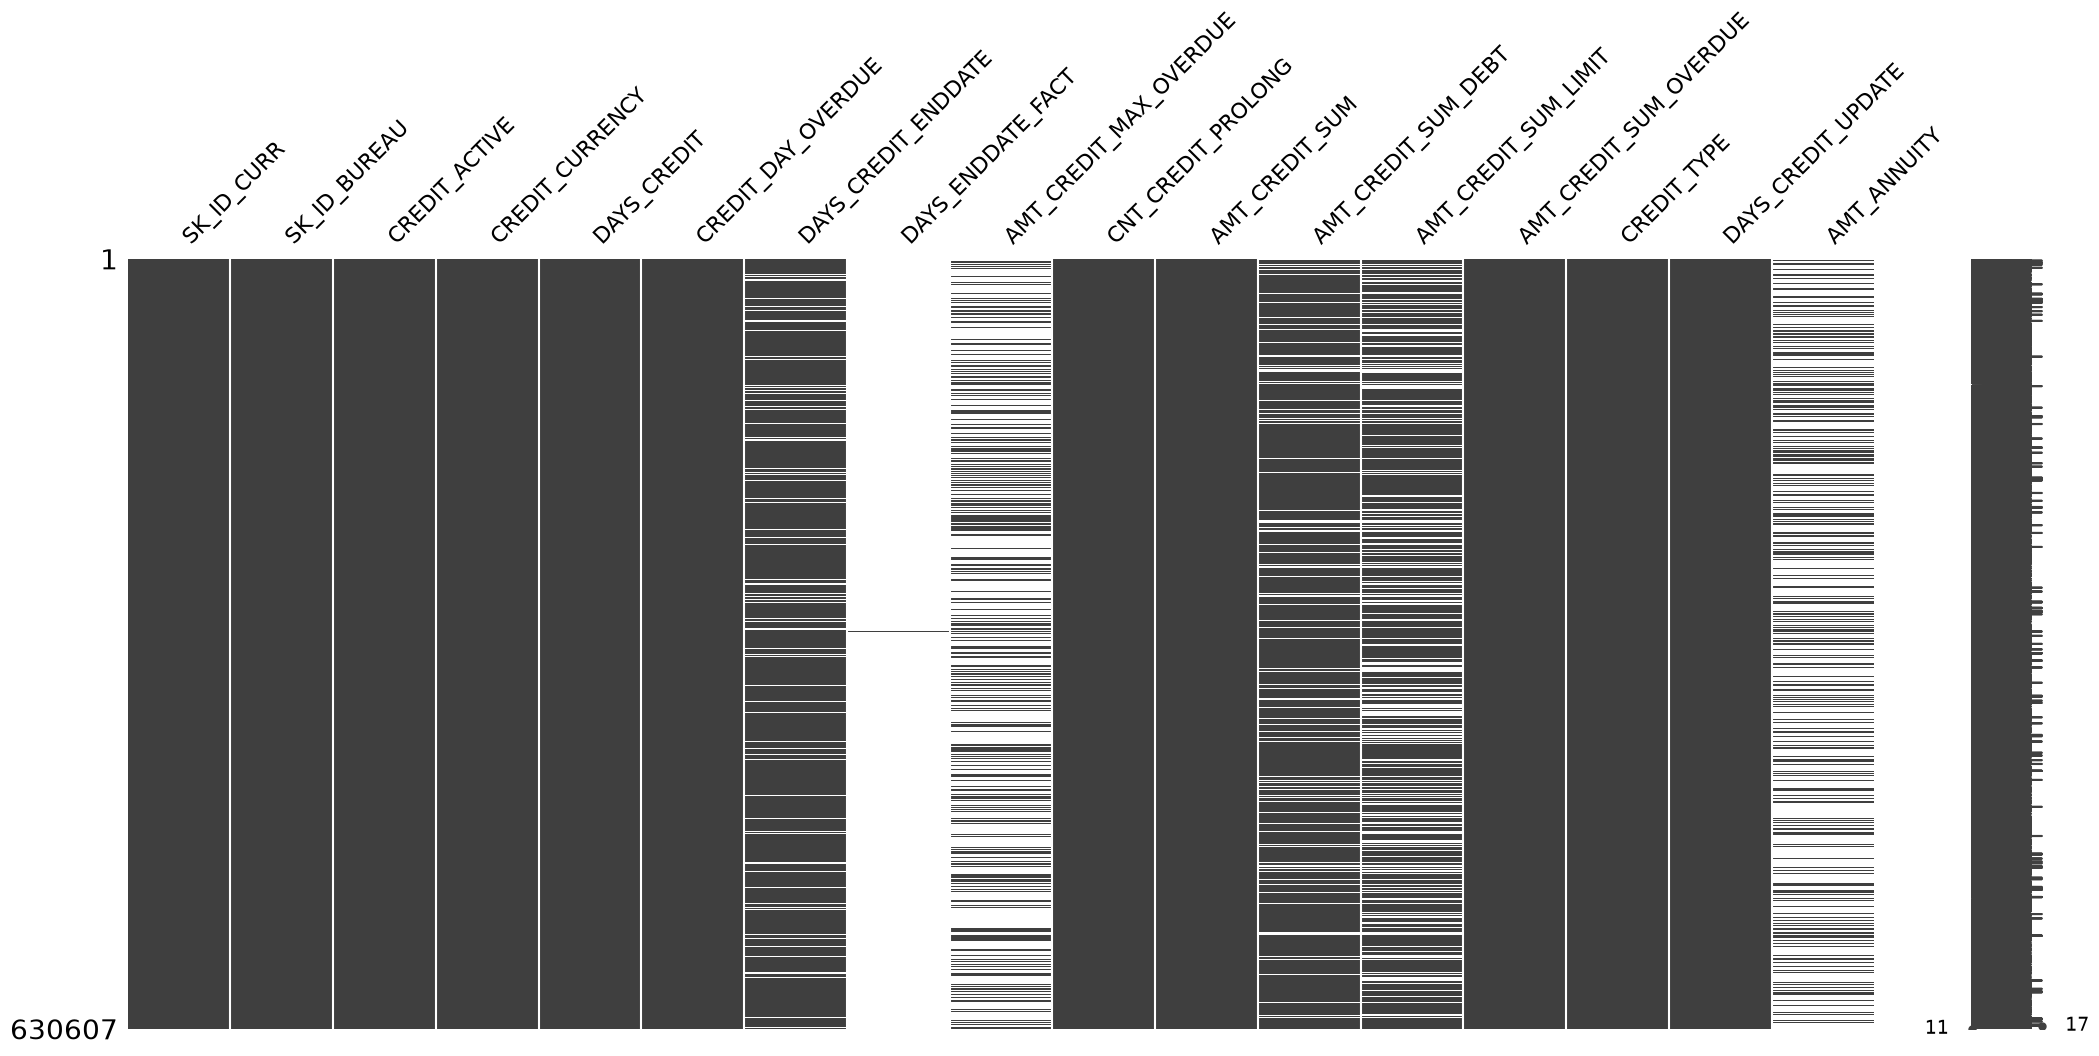

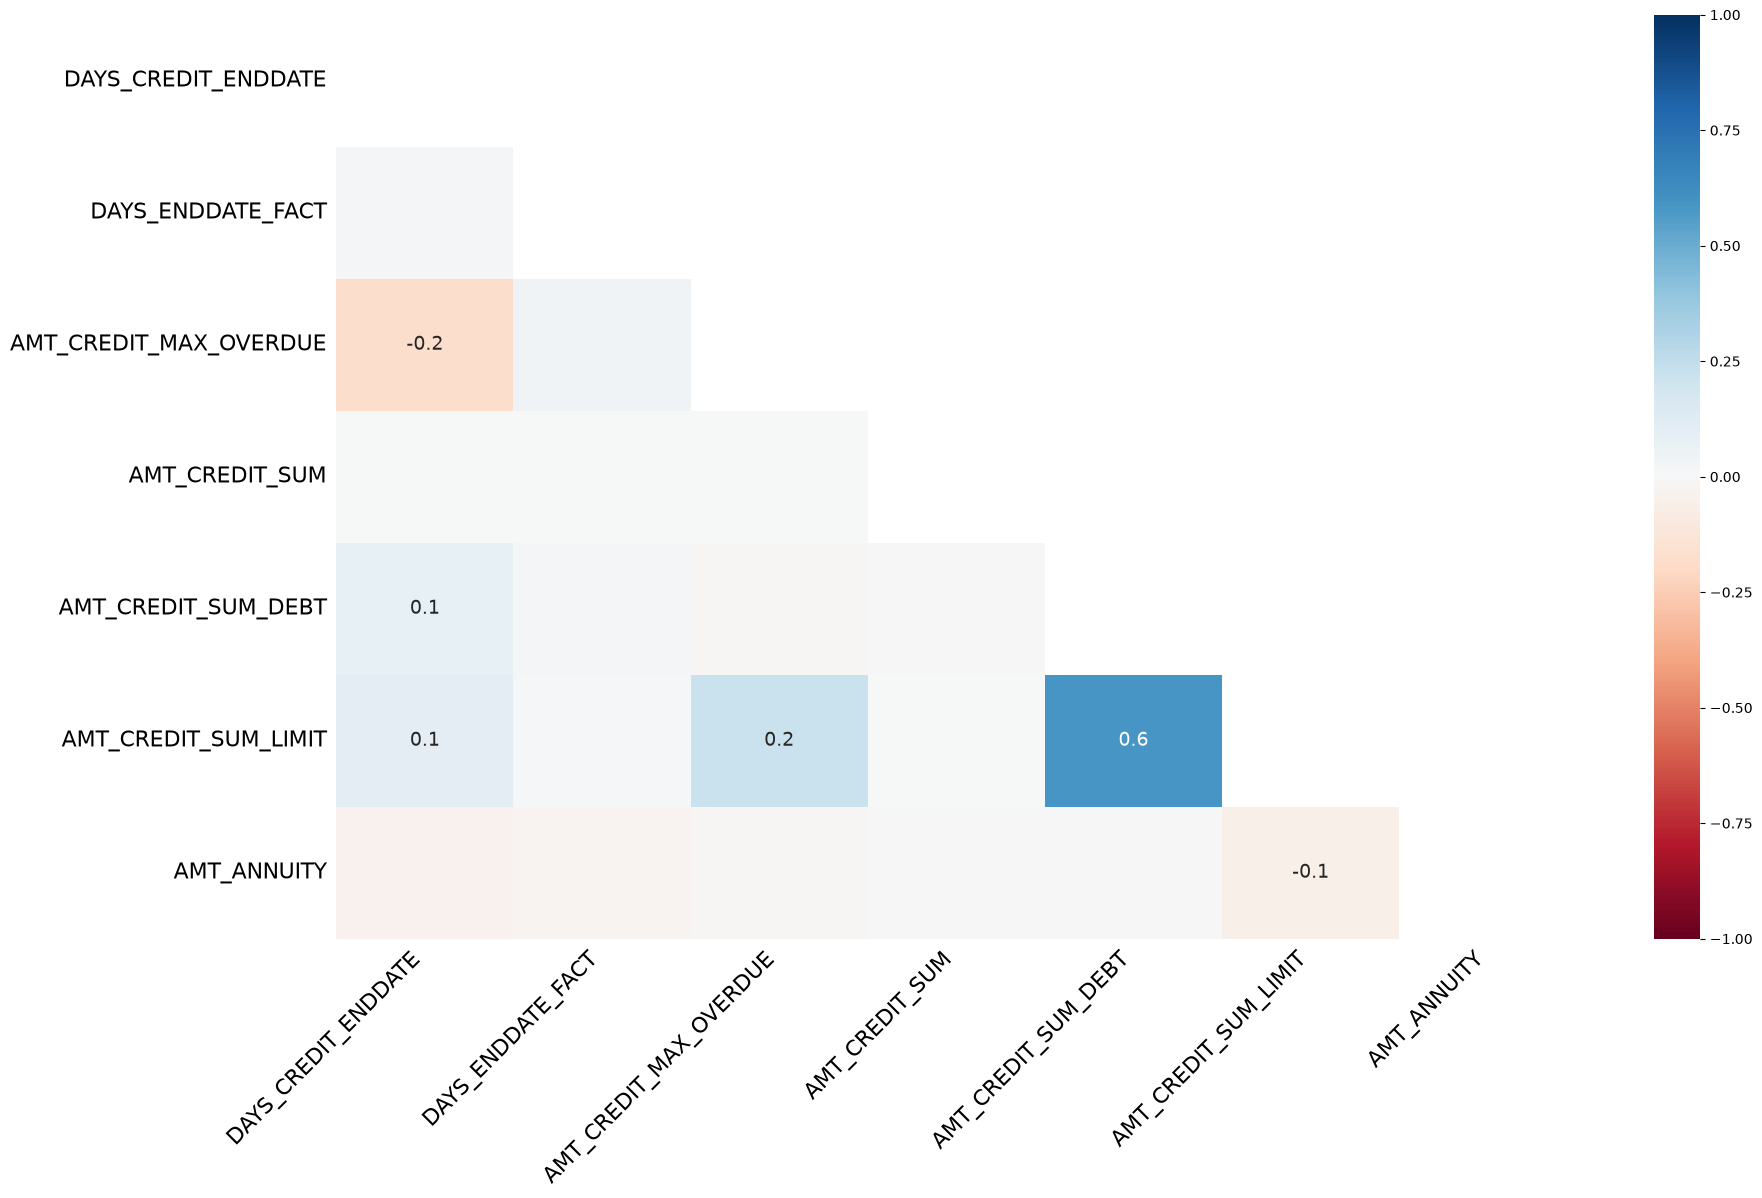

In [ ]:
import missingno as msno

# Missing-value pattern across the full, unfiltered bureau.csv (no
# CREDIT_ACTIVE/DAYS_ENDDATE_FACT filtering applied here) before deciding how
# to handle nulls in any utilisation feature.
msno.matrix(active)
plt.show()

# Nullity correlation: whether missingness in one column tends to co-occur
# with missingness in another, to spot columns that go missing together.
msno.heatmap(active)
plt.show()

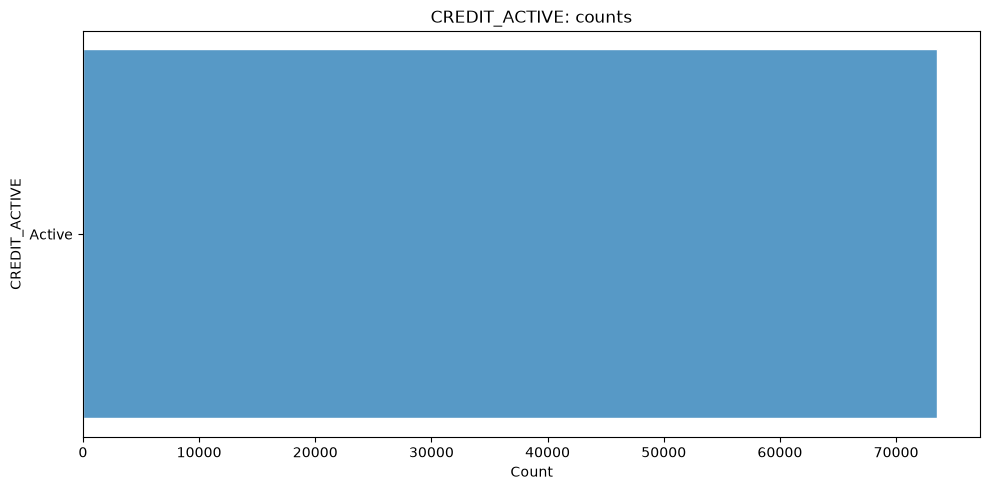

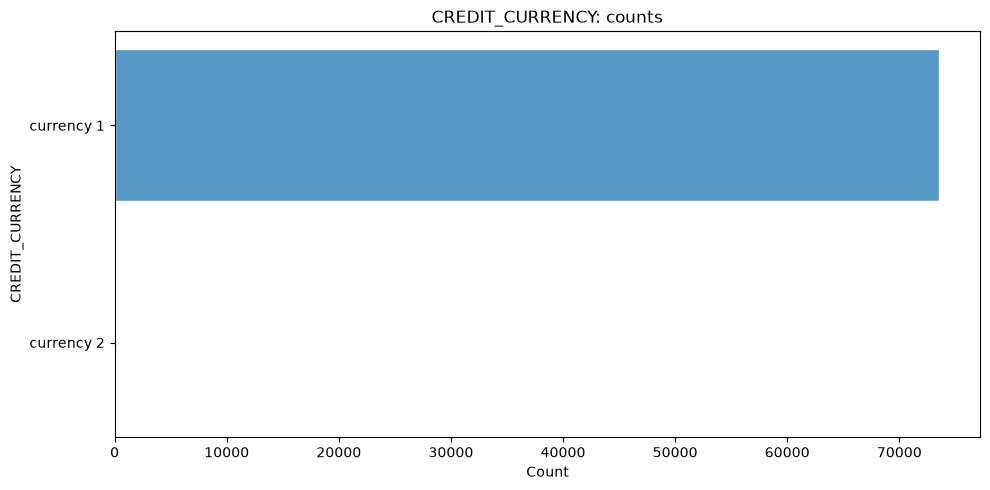

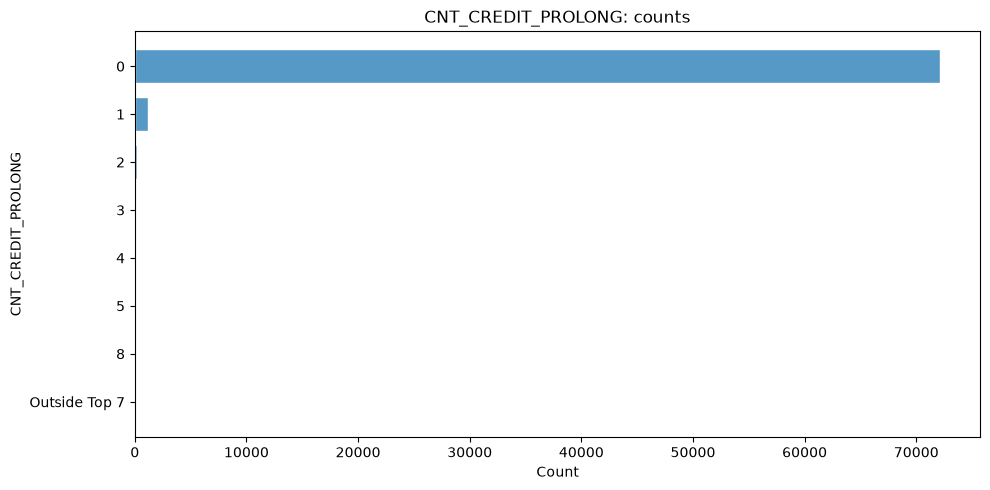

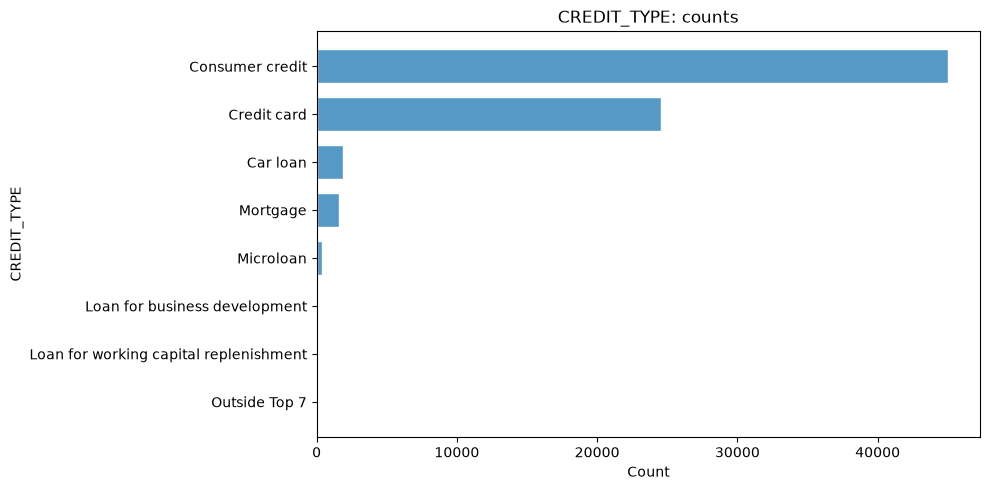

In [ ]:
from column_analysis import infer_semantic_type
active_nans = active[active[""""AMT_CREDIT_SUM"""_DEBT"].isna()]

categorical_cols = [col for col in active_nans.columns if not pd.api.types.is_datetime64_any_dtype(active_nans[col]) and (
            not pd.api.types.is_numeric_dtype(active_nans[col])
            or infer_semantic_type(active_nans[col]) in {"binary", "categorical (integer-coded)"}
            and col not in ["SK_ID_CURR", "SK_ID_BUREAU"]
        )]

numerical_cols = [col for col in active_nans.columns if pd.api.types.is_numeric_dtype(active_nans[col]) 
                 and infer_semantic_type(active_nans[col]) not in {"binary", "categorical (integer-coded)"}
                 and col not in ["SK_ID_CURR", "SK_ID_BUREAU", "AMT_CREDIT_SUM_DEBT"]]

# --- numerical columns: histogram + boxplot, split by TARGET ---
# for num_col in numerical_cols:
#     fig, ax = plt.subplots(1, 2, figsize=(14, 5))
#     histogram_by_class(active_nans, num_col, ax=ax[0])
#     boxplot_by_class(active_nans, num_col, ax=ax[1])
#     plt.tight_layout()
#     plt.show()

# --- categorical columns: bar chart, split by TARGET ---
for cat_col in categorical_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    active_nans_copy = active_nans.copy()
    active_nans_copy[cat_col] = active_nans_copy[cat_col].fillna("Missing")
    bar_chart(active_nans_copy, cat_col, ax=ax, top_n=7)
    plt.tight_layout()
    plt.show()

So we see from the both the missing value plots, and also the histograms, that having `AMT_CREDIT_SUM_DEBT` == NaN has no clear relation with any of the other variables. This is evidenced from variables like `AMT_OWED` == 0, which is an indicator of a good borrower (no default, late payment), and yet these columns still have their AMT_CREDIT_SUM_DEBT == NaN, which should indicate some kind of data quality issue.

This complicates the analysis because there seems to be no information that can be extracted from these columns in making debt_ratio columns. The only thing left to do is to drop is one of two things:

1. Flag this column as being NaN and test the correlation with default. 
2. Drop all the NaN columns and work exclusively with `AMT_CREDIT_SUM_DEBT` with no entries that are 0 to create the credit utilisation column. Furthermore, after investigation into the `AMT_CREDIT_SUM` variables, it is found that there are only 8 NaNs. so these variables are dropped as well.

The former is something that can be looked into later, but for now it makes more sense to create a credit utilisation variable for the entries that are available. 

### Feature Engineering for Active

The idea is to create the following two features:
1. `BUREAU_UTIL_POOLED` - The total credit utilisation ratio of a specific customer based on bureau data. 
2. `BUREAU_UTIL_MAX` - For a consumer, their maximum credit utilisation based on bureau data.

Both features work with by dividing `AMT_CREDIT_SUM_DEBT` (outstanding balance) with `AMT_CREDIT_SUM` (principal), so it is essential that we observe for `AMT_CREDIT_SUM` != 0/ NaN. Hunting for these values will be the focus of the section, and we will focus on creating high quality versions of these features.

In [14]:
bureau_clean = active.dropna(subset=["AMT_CREDIT_SUM_DEBT", "AMT_CREDIT_SUM"])

#from column_analysis import basic_data_summary
from column_analysis import TypeTable, MissingValueTable, NumericalSummaryTable, CategoricalSummaryTable

# Basic summary 
#basic_data_summary(active)

# Type table 
print("\n" + "=" * 100)
print("1. VARIABLE TYPES")
print("=" * 100)
type_table = TypeTable()
print(type_table.plot_table(bureau_clean).to_string())


# Missing table
print("\n" + "=" * 100)
print("2. MISSING VALUE ANALYSIS")
print("=" * 100)
missing_table = MissingValueTable()
print(missing_table.plot_table(bureau_clean).to_string())

print("\n" + "=" * 100)
print("3a. NUMERICAL SUMMARY")
print("=" * 100)
numerical_table = NumericalSummaryTable()
print(numerical_table.plot_table(bureau_clean).to_string())

print("\n" + "=" * 100)
print("3b. CATEGORICAL SUMMARY")
print("=" * 100)
cat_table = CategoricalSummaryTable()
print(cat_table.plot_table(bureau_clean).to_string())


1. VARIABLE TYPES
                          dtype                inferred_type  n_unique  unique_ratio      example  memory_mb
column                                                                                                      
SK_ID_CURR                int64           numeric (discrete)    239861        0.4306       215354       8.50
SK_ID_BUREAU              int64         identifier (numeric)    557052        1.0000      5714463       8.50
CREDIT_ACTIVE               str                     constant         1        0.0000       Active      33.47
CREDIT_CURRENCY             str                  categorical         4        0.0000   currency 1      35.59
DAYS_CREDIT               int64           numeric (discrete)      2923        0.0052         -208       8.50
CREDIT_DAY_OVERDUE        int64           numeric (discrete)       685        0.0012            0       8.50
DAYS_CREDIT_ENDDATE     float64           numeric (discrete)     11904        0.0214       1075.0       8.50


In [32]:
# Before building the utilisation ratio, check what AMT_CREDIT_SUM == 0
# rows actually look like - a 0 denominator would otherwise silently
# produce inf/NaN in the ratio below.
bureau_clean = active.dropna(subset=["AMT_CREDIT_SUM_DEBT", "AMT_CREDIT_SUM"])
zero_sum = bureau_clean[bureau_clean["AMT_CREDIT_SUM"] == 0]

print(f"rows with AMT_CREDIT_SUM == 0: {len(zero_sum):,} of {len(bureau_clean):,} "
      f"({100 * len(zero_sum) / len(bureau_clean):.2f}%)")
print()
print("--- CREDIT_TYPE breakdown ---")
print(zero_sum["CREDIT_TYPE"].value_counts())
print()

# Split by what AMT_CREDIT_SUM_DEBT looks like alongside the 0 sum.
print("n with debt == 0 too (both zero):", (zero_sum["AMT_CREDIT_SUM_DEBT"] == 0).sum())
print("n with debt > 0 (debt but no reported sum):", (zero_sum["AMT_CREDIT_SUM_DEBT"] > 0).sum())
print("n with debt < 0 (credit balance/overpayment):", (zero_sum["AMT_CREDIT_SUM_DEBT"] < 0).sum())
print()

# How many customers are affected at all, vs. affected on every one of
# their active credits (pooled ratio undefined no matter what for these).
affected_customers = zero_sum["SK_ID_CURR"].nunique()
all_zero_per_customer = bureau_clean.groupby("SK_ID_CURR")["AMT_CREDIT_SUM"].apply(lambda s: (s == 0).all())
print(f"customers with >=1 active AMT_CREDIT_SUM==0 credit: {affected_customers:,} "
      f"of {bureau_clean['SK_ID_CURR'].nunique():,}")
print(f"customers where EVERY active credit has AMT_CREDIT_SUM==0: {all_zero_per_customer.sum():,}")

rows with AMT_CREDIT_SUM == 0: 35,902 of 557,052 (6.44%)

--- CREDIT_TYPE breakdown ---
CREDIT_TYPE
Credit card             35828
Consumer credit            50
Another type of loan       24
Name: count, dtype: int64

n with debt == 0 too (both zero): 31155
n with debt > 0 (debt but no reported sum): 1972
n with debt < 0 (credit balance/overpayment): 2775

customers with >=1 active AMT_CREDIT_SUM==0 credit: 28,289 of 239,861
customers where EVERY active credit has AMT_CREDIT_SUM==0: 4,154


35,902 rows (6.44% of the cleaned active data) have `AMT_CREDIT_SUM == 0`, and this is overwhelmingly a **credit card** phenomenon (35,828 of 35,902 rows, 99.8%). Within these:

1. 31,155 (87%) also have `AMT_CREDIT_SUM_DEBT == 0` - genuinely empty/closed-out cards with no reported limit, internally consistent, safe to treat as 0 utilisation (or exclude from the ratio).
2. 1,972 have positive debt against a 0 reported sum - a real anomaly: debt owed on a card with no reported credit amount, the same "limit not reported" data-quality pattern seen earlier with `AMT_CREDIT_SUM_LIMIT`.
3. 2,775 have *negative* debt (a credit balance/overpayment) against a 0 sum.
4. 4,154 of 239,861 customers (1.7%) have **every** active credit at `AMT_CREDIT_SUM == 0` - the pooled ratio is undefined (NaN or inf) for these customers no matter how the per-row cases above are handled.

Given this, rows with `AMT_CREDIT_SUM == 0` are excluded from the utilisation calculation below (same treatment as the `AMT_CREDIT_SUM_DEBT` NaN rows already dropped) rather than coerced to 0 or left to produce `inf` - the anomalous non-zero-debt cases (groups 2-3) are too small a share (~13% of the zero-sum rows) to justify a special rule, and folding them into a 0-or-inf ratio would distort the distribution more than dropping them.

In [5]:
# Drop rows where any side of the utilisation ratio is unusable:
# - AMT_CREDIT_SUM_DEBT NaN has no usable signal to impute from (see above).
# - AMT_CREDIT_SUM NaN is only 8 rows.
# - AMT_CREDIT_SUM == 0 is excluded per the investigation above - mostly
#   internally-consistent empty cards (debt also 0), but a 0 denominator
#   would otherwise produce inf/NaN in the ratio for the small remaining
#   anomalous share.
bureau_clean = active.dropna(subset=["AMT_CREDIT_SUM_DEBT", "AMT_CREDIT_SUM"])
bureau_clean = bureau_clean[bureau_clean["AMT_CREDIT_SUM"] != 0]

# Cap the per-credit ratio via a standard IQR (Tukey) fence rather than a
# hand-picked round number - both easier to justify and appropriate here since
# these features get tree-bucketed downstream anyway, so a small share of rows
# landing exactly at the cap boundary does not distort the bucketing.
per_credit_util_raw = bureau_clean["AMT_CREDIT_SUM_DEBT"] / bureau_clean["AMT_CREDIT_SUM"]
q1, q3 = per_credit_util_raw.quantile([0.25, 0.75])
iqr = q3 - q1
UTIL_RATIO_LOWER_CAP = q1 - 1.5 * iqr
UTIL_RATIO_UPPER_CAP = q3 + 1.5 * iqr

# --- 1. Pooled utilisation: total debt over total credit extended, summed
# across a customer's active credits before dividing, so a small unused
# line can't dilute a maxed-out one. Capped after dividing, not before -
# capping the raw debt/sum inputs would distort the pooling itself. ---
bureau_totals = bureau_clean.groupby("SK_ID_CURR")[
    ["AMT_CREDIT_SUM_DEBT", "AMT_CREDIT_SUM"]
].sum()
bureau_util_pooled = (
    bureau_totals["AMT_CREDIT_SUM_DEBT"] / bureau_totals["AMT_CREDIT_SUM"]
).clip(UTIL_RATIO_LOWER_CAP, UTIL_RATIO_UPPER_CAP).rename("BUREAU_UTIL_POOLED")

# --- 2. Max utilisation: the single most-utilised active credit line per
# customer - a "worst case" signal, since being maxed out on any one line
# can be predictive even when the blended/pooled ratio looks fine. Capped
# per-credit before taking the max, so one erroneous row can't single-handedly
# set a customer's max. ---
per_credit_util = per_credit_util_raw.clip(UTIL_RATIO_LOWER_CAP, UTIL_RATIO_UPPER_CAP)
bureau_util_max = (
    per_credit_util.groupby(bureau_clean["SK_ID_CURR"]).max()
).rename("BUREAU_UTIL_MAX")

bureau_util_features = pd.concat([bureau_util_pooled, bureau_util_max], axis=1)
bureau_util_features.describe()

,BUREAU_UTIL_POOLED,BUREAU_UTIL_MAX
count,235707.000000,235707.000000
mean,0.599442,0.731115
std,0.321357,0.358030
min,-0.913877,-0.913877
25%,0.379001,0.552939
50%,0.671000,0.865109
75%,0.858445,0.968851
max,2.012373,2.012373


#### Possible Improvements 
- Weight the pooled variables by how recent the information is 
- Weight the utilisation max by the magnitude of the actual credit limit (if the balance is small but utilisation ratio is high, then clearly its a piece of redundant information)

### Delinquency History Data 
After creating a credit utilisation feature, the next course of action is to create a feature that captures the recent payment performance of a previous credit, in terms of the default count. Two features will be created:

1. `BUREAU_NUM_OVERDUE`: number of active entries with `CREDIT_DAY_OVERDUE` > 0 (recall we are still working with `CREDIT_STATUS` == "Active"). This feature captures among the active credits, how many days since the last instalment deadline is the credit overdue.
2. `BUREAU_REPAYMENT_HISTORY`: captures the number of months the balance was lower than the previous month. 

In [6]:
# Default-frequency flags from CREDIT_DAY_OVERDUE, restricted to active
# credits (same  frame used for the utilisation features above).
# CREDIT_DAY_OVERDUE > 0 is rare (~1.3% of customers have any nonzero value
# at all), so a single tiered bucket would mostly be empty - instead build
# several binary threshold flags at once ("was this credit ever more than
# X days overdue") and let a later correlation pass pick which X actually
# separates TARGET best, rather than committing to one cutoff now.
DPD_THRESHOLDS = [0, 30, 60, 90, 180, 365]

dpd_flags = pd.DataFrame(
    {
        f"NUM_CREDITS_{x}D_DPD": (active["CREDIT_DAY_OVERDUE"] > x).astype(int)
        for x in DPD_THRESHOLDS
    },
    index=active.index,
)

# Sum each flag up to one row per customer - how many of a customer's
# active credits have ever been overdue past each threshold.
delinquency_features = dpd_flags.groupby(active["SK_ID_CURR"]).sum()

In [ ]:
# Cast to category dtype so CategoricalSummaryTable picks these columns up
# (each is a small set of counts, not a continuous measurement).
delinquency_features = delinquency_features.astype("category")

from column_analysis import CategoricalSummaryTable

cat_table = CategoricalSummaryTable()
print(cat_table.plot_table(delinquency_features).to_string())



                       count  n_unique  top_1  top_2  top_3  top_4  top_5
column                                                                   
NUM_CREDITS_0D_DPD    251815         8      0      1      2      3    4.0
NUM_CREDITS_30D_DPD   251815         7      0      1      2      3    4.0
NUM_CREDITS_60D_DPD   251815         6      0      1      2      3    4.0
NUM_CREDITS_90D_DPD   251815         6      0      1      2      3    5.0
NUM_CREDITS_180D_DPD  251815         5      0      1      2      3    4.0
NUM_CREDITS_365D_DPD  251815         4      0      1      2      3    NaN


In [12]:
# Composition of each DPD-threshold flag: bar chart (raw counts) and pie
# chart (share of customers) side by side, one row per threshold.
for col in delinquency_features.columns:
    print(delinquency_features[col].value_counts(ascending=True).to_string())
    print("\n")
    

NUM_CREDITS_0D_DPD
7         1
6         4
5         6
4        13
3        37
2       179
1      3462
0    248113


NUM_CREDITS_30D_DPD
7         1
5         3
4         4
3        17
2        56
1      1837
0    249897


NUM_CREDITS_60D_DPD
4         2
5         2
3        12
2        34
1      1224
0    250541


NUM_CREDITS_90D_DPD
4         1
5         2
3         9
2        28
1      1009
0    250766


NUM_CREDITS_180D_DPD
4         1
3         5
2        28
1       733
0    251048


NUM_CREDITS_365D_DPD
3         2
2        18
1       636
0    251159




### Combining Bureau Features

Merge every bureau-derived feature built above into one dataframe, one row
per `SK_ID_CURR`: the utilisation features (`bureau_util_features` -
`BUREAU_UTIL_POOLED`/`BUREAU_UTIL_MAX`, built from `bureau_clean` - active
credits only, NaN/zero-sum rows dropped) and the delinquency features
(`delinquency_features` - the six `NUM_CREDITS_{X}D_DPD` counts, built from
the full `active` frame). `bureau_util_features`'s customers are a strict
subset of `delinquency_features`'s (235,707 of 251,815) - the outer join
below leaves `BUREAU_UTIL_POOLED`/`BUREAU_UTIL_MAX` as NaN for the 16,108
customers whose active credits were all dropped by the utilisation-side
filtering, rather than silently losing those customers' delinquency counts.

In [7]:
bureau_features = pd.concat([bureau_util_features, delinquency_features], axis=1)

print(f"bureau_util_features customers: {len(bureau_util_features):,}")
print(f"delinquency_features customers: {len(delinquency_features):,}")
print(f"bureau_features (combined) customers: {len(bureau_features):,}")

bureau_features.head()

bureau_util_features customers: 235,707
delinquency_features customers: 251,815
bureau_features (combined) customers: 251,815


,BUREAU_UTIL_POOLED,BUREAU_UTIL_MAX,NUM_CREDITS_0D_DPD,NUM_CREDITS_30D_DPD,NUM_CREDITS_60D_DPD,NUM_CREDITS_90D_DPD,NUM_CREDITS_180D_DPD,NUM_CREDITS_365D_DPD
SK_ID_CURR,,,,,,,,
100001,0.674966,0.987405,0,0,0,0,0,0
100002,0.509931,0.546180,0,0,0,0,0,0
100003,0.000000,0.000000,0,0,0,0,0,0
100005,0.949522,0.954794,0,0,0,0,0,0
100008,0.897054,0.897054,0,0,0,0,0,0


# `installments_payments` Data Analysis

In [8]:
df = pd.read_csv("home_credit/installments_payments.csv")
df.head()

df = df[df["DAYS_ENTRY_PAYMENT"] > -365] 

In [110]:
"""Column-level analysis of a dataset.

Produces, for every column:
  1. Variable types   - pandas dtype, an inferred semantic type, and cardinality.
  2. Missing values   - count and percentage of nulls (blank/whitespace strings
                        and common null placeholders are treated as missing).
  3. Summary          - describe() for numeric/datetime columns, value counts and
                        top categories for object/categorical columns.

Requires the `data_science` conda environment (pandas 3.0.3, numpy 2.5.1):

    conda activate data_science
    python credit_risk/loan_column_analysis.py

Without activating, call the environment's interpreter directly:

    ~/anaconda3/envs/data_science/python.exe credit_risk/loan_column_analysis.py

To analyse a different file or a row-capped sample, edit DATA_PATH / SAMPLE below.
"""

from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

#DATA_PATH = Path(__file__).resolve().parent / "home_credit" / "bureau.csv"
#SAMPLE = None  # int to read only the first N rows, None for the full file

# # Strings that mean "no value" but are not read as NaN by default.
# NULL_TOKENS = {"", "na", "n/a", "nan", "null", "none", "-", "?", "unknown", "missing"}

# A column with few distinct values relative to its length is treated as
# categorical even when stored as text or as an integer-valued float.
CATEGORICAL_MAX_UNIQUE = 50
CATEGORICAL_MAX_RATIO = 0.05

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

def load(path: Path, sample: int | None) -> pd.DataFrame:
    """Read the CSV, letting pandas infer dtypes, with an optional row cap."""
    df = pd.read_csv(path, nrows=sample, low_memory=False)
    # Parse the date-ish columns so they summarise as dates rather than strings.
    for col, fmt in (("issue_d", "%b-%y"), ("issue_date", "%B %Y")):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format=fmt, errors="coerce")
    return df


# def normalise_missing(df: pd.DataFrame) -> pd.DataFrame:
#     """Turn placeholder strings ('', ' ', 'N/A', ...) into real NaNs."""
#     out = df.copy()
#     for col in out.columns:
#         if out[col].dtype == object:
#             stripped = out[col].astype("string").str.strip()
#             out[col] = stripped.mask(stripped.str.lower().isin(NULL_TOKENS))
#     return out


def infer_semantic_type(s: pd.Series) -> str:
    """Label a column beyond its raw dtype: id / binary / categorical / ..."""
    non_null = s.dropna()
    if non_null.empty:
        return "empty"

    n_unique = non_null.nunique()
    ratio = n_unique / len(non_null)

    if pd.api.types.is_datetime64_any_dtype(s):
        return "datetime"
    if pd.api.types.is_bool_dtype(s) or n_unique == 2:
        return "binary"
    if n_unique == 1:
        return "constant"
    if pd.api.types.is_numeric_dtype(s):
        is_whole = bool((non_null % 1 == 0).all())
        # Near-unique integers are almost always identifiers, not measurements.
        if ratio > 0.99 and is_whole:
            return "identifier (numeric)"
        if is_whole:
            if n_unique <= CATEGORICAL_MAX_UNIQUE:
                return "categorical (integer-coded)"
            return "numeric (discrete)"
        return "numeric (continuous)"
    if ratio > 0.99:
        return "identifier (text)"
    if n_unique <= CATEGORICAL_MAX_UNIQUE or ratio <= CATEGORICAL_MAX_RATIO:
        return "categorical"
    return "text / high-cardinality"


def type_table(df: pd.DataFrame) -> pd.DataFrame:
    """Section 1: dtype, inferred type, cardinality and an example value."""
    rows = []
    for col in df.columns:
        s = df[col]
        non_null = s.dropna()
        rows.append(
            {
                "column": col,
                "dtype": str(s.dtype),
                "inferred_type": infer_semantic_type(s),
                "n_unique": int(non_null.nunique()),
                "unique_ratio": round(non_null.nunique() / len(s), 4) if len(s) else np.nan,
                "example": (str(non_null.iloc[0])[:40] if not non_null.empty else ""),
                "memory_mb": round(s.memory_usage(deep=True) / 1024**2, 2),
            }
        )
    return pd.DataFrame(rows).set_index("column")


def missing_table(raw: pd.DataFrame, clean: pd.DataFrame) -> pd.DataFrame:
    """Section 2: nulls per column, split into true NaNs and placeholders."""
    n = len(clean)
    rows = []
    for col in clean.columns:
        native = int(raw[col].isna().sum())
        total = int(clean[col].isna().sum())
        rows.append(
            {
                "column": col,
                "n_missing": total,
                "pct_missing": round(100 * total / n, 2) if n else np.nan,
                "n_native_nan": native,
                "n_placeholder": total - native,  # '', 'N/A', 'unknown', ...
                "n_present": n - total,
                "complete": total == 0,
            }
        )
    return pd.DataFrame(rows).set_index("column").sort_values("pct_missing", ascending=False)


def summarise_numerical_column(s: pd.Series) -> None:
    """Print describe() plus skew/kurtosis for a numerical column."""
    non_null = s.dropna()
    desc = non_null.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    print(desc.to_string())
    print(f"  skew={non_null.skew():.3f}  kurtosis={non_null.kurtosis():.3f}  "
          f"zeros={int((non_null == 0).sum())}  negatives={int((non_null < 0).sum())}")


def summarise_categorical_column(s: pd.Series) -> None:
    """Print value counts and top categories for a categorical column, keeping NaN as its own category."""
    counts = s.value_counts(dropna=False)
    print(f"  n_unique={counts.size}")
    print("  top values:")
    top = counts.head(15)
    pct = (100 * top / len(s)).round(2)
    print(pd.DataFrame({"count": top, "pct_of_rows": pct}).to_string())
    if counts.size > 15:
        print(f"  ... {counts.size - 15} further categories")


def summarise_datetime_column(s: pd.Series) -> None:
    """Print describe() and a by-year breakdown for a datetime column."""
    non_null = s.dropna()
    print(non_null.describe().to_string())
    print("  by year:")
    print(non_null.dt.year.value_counts().sort_index().to_string())


def summarise_column(s: pd.Series, name: str) -> None:
    """Section 3: dispatch to the summary appropriate to the column's type."""
    kind = infer_semantic_type(s)
    print(f"\n--- {name}  [dtype={s.dtype}, inferred={kind}] ---")

    non_null = s.dropna()
    if non_null.empty:
        print("  (all values missing)")
        return

    if pd.api.types.is_numeric_dtype(s) and kind not in {"binary", "categorical (integer-coded)"}:
        summarise_numerical_column(s)
    elif pd.api.types.is_datetime64_any_dtype(s):
        summarise_datetime_column(s)
    else:
        summarise_categorical_column(s)


def main() -> None:
    raw = df
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"Fully duplicated rows: {int(df.duplicated().sum()):,}")

    print("\n" + "=" * 100)
    print("1. VARIABLE TYPES")
    print("=" * 100)
    print(type_table(df).to_string())

    print("\n" + "=" * 100)
    print("2. MISSING VALUE ANALYSIS")
    print("=" * 100)
    miss = missing_table(raw, df)
    print(miss.to_string())
    incomplete = miss[~miss["complete"]]
    print(f"\nColumns with missing data: {len(incomplete)} of {df.shape[1]}")
    print(f"Rows with at least one missing value: {int(df.isna().any(axis=1).sum()):,} "
          f"({100 * df.isna().any(axis=1).mean():.2f}%)")
    print(f"Complete rows: {int((~df.isna().any(axis=1)).sum()):,}")

    print("\n" + "=" * 100)
    print("3. PER-COLUMN SUMMARY")
    print("=" * 100)
    numerical_cols, datetime_cols, categorical_cols = [], [], []
    for col in df.columns:
        s = df[col]
        kind = infer_semantic_type(s)
        if pd.api.types.is_numeric_dtype(s) and kind not in {"binary", "categorical (integer-coded)"}:
            numerical_cols.append(col)
        elif pd.api.types.is_datetime64_any_dtype(s):
            datetime_cols.append(col)
        else:
            categorical_cols.append(col)

    for label, cols in (
        ("Numerical columns", numerical_cols),
        ("Datetime columns", datetime_cols),
        ("Categorical columns", categorical_cols),
    ):
        print(f"\n--- {label} ---")
        for col in cols:
            summarise_column(df[col], col)

    print("\n" + "=" * 100)
    print("Numeric columns, describe() side by side")
    print("=" * 100)
    num = df.select_dtypes(include=[np.number])
    if not num.empty:
        print(num.describe().T.to_string())


if __name__ == "__main__":
    main()




Shape: 3,347,117 rows x 8 columns
Memory: 229.8 MB
Fully duplicated rows: 0

1. VARIABLE TYPES
                          dtype         inferred_type  n_unique  unique_ratio  example  memory_mb
column                                                                                           
SK_ID_PREV                int64    numeric (discrete)    390695        0.1167  2085231      51.07
SK_ID_CURR                int64    numeric (discrete)    250607        0.0749   193053      51.07
NUM_INSTALMENT_VERSION  float64    numeric (discrete)        60        0.0000      2.0      51.07
NUM_INSTALMENT_NUMBER     int64    numeric (discrete)       277        0.0001        1      51.07
DAYS_INSTALMENT         float64    numeric (discrete)      1394        0.0004    -63.0      51.07
DAYS_ENTRY_PAYMENT      float64    numeric (discrete)       364        0.0001    -63.0      51.07
AMT_INSTALMENT          float64  numeric (continuous)    557122        0.1664  25425.0      51.07
AMT_PAYMENT            

From the analysis - it seems clearly that the most interesting columns are the lateness of payments: for that reason we will make a plot of the length of lateness of payments only instead of plotting both the days_instalment and `DAYS_ENTRY_PAYMENT`

In [111]:
df['LATE_PAYMENT'] = df["DAYS_ENTRY_PAYMENT"] - df['DAYS_INSTALMENT']

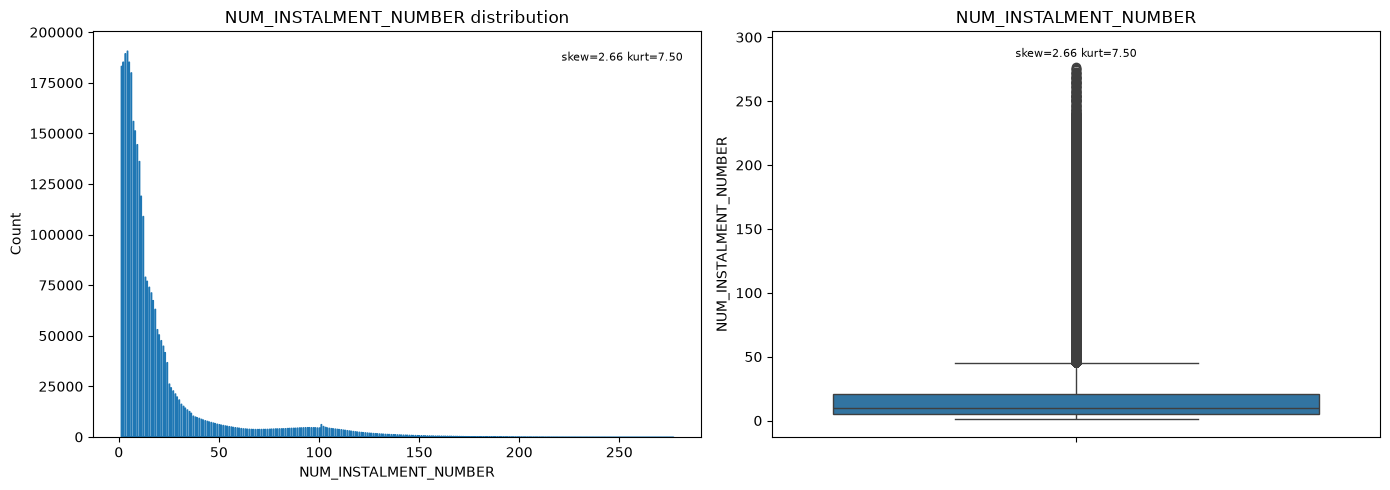

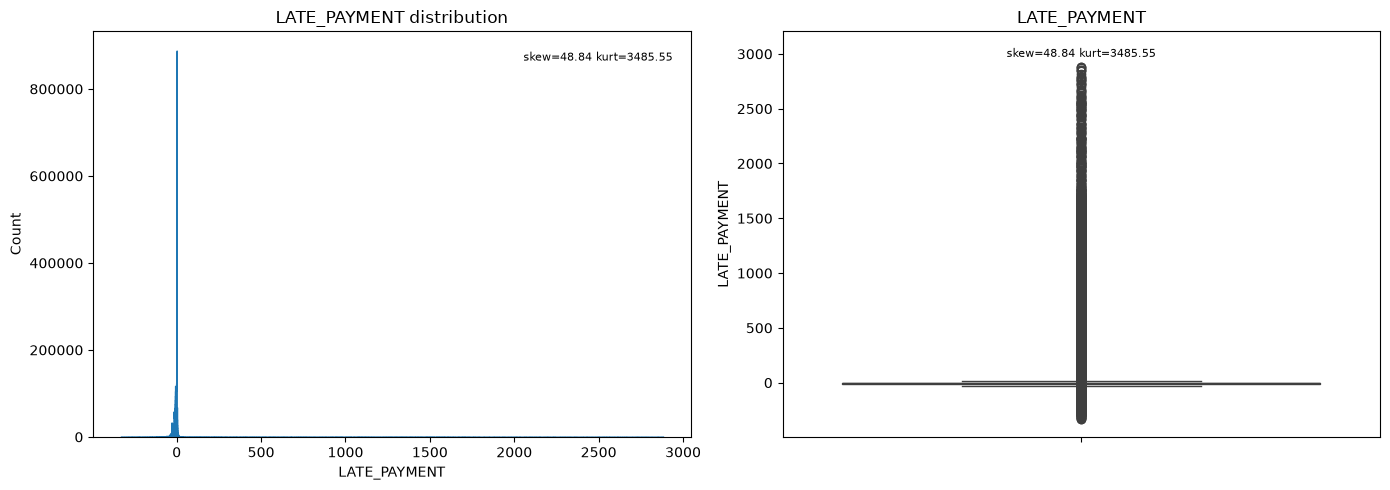

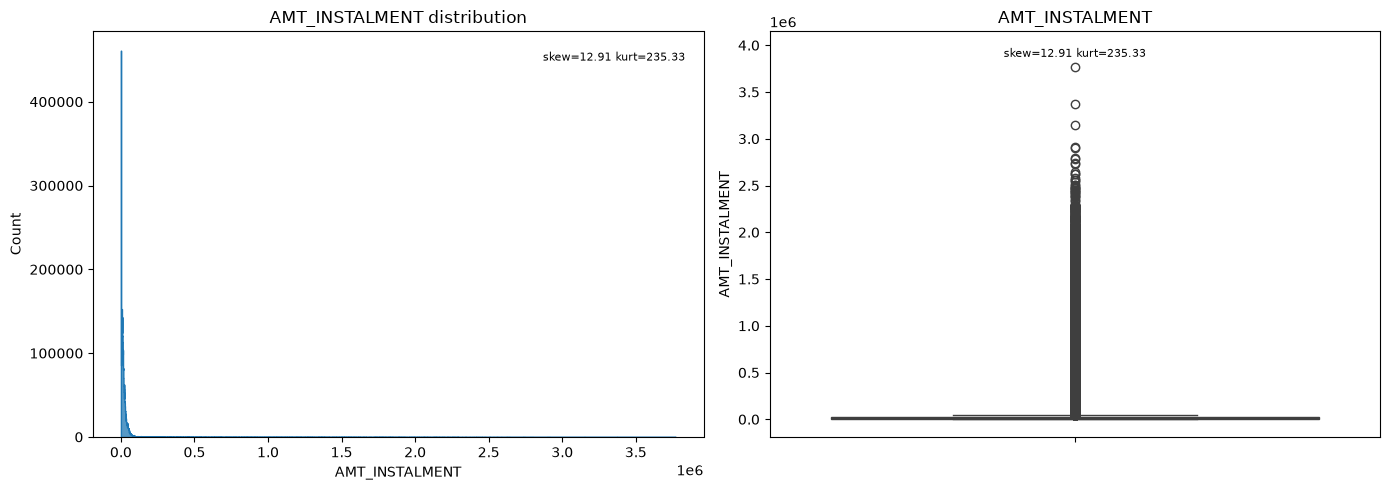

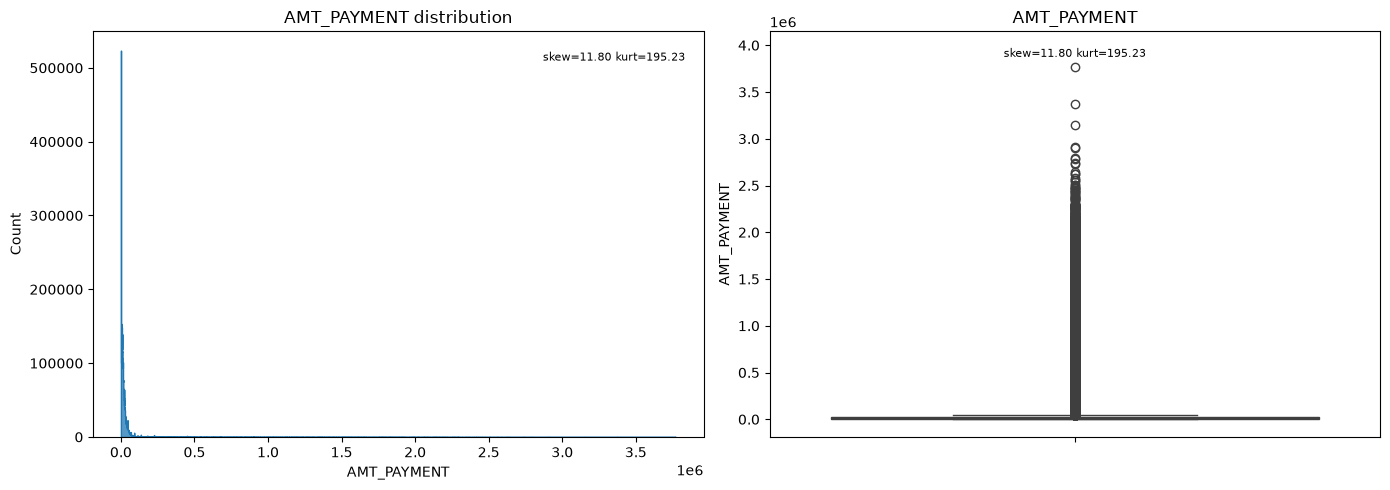

In [112]:
NUM_COLUMNS = ["NUM_INSTALMENT_NUMBER", "LATE_PAYMENT", 'AMT_INSTALMENT', "AMT_PAYMENT"]

for num_col in NUM_COLUMNS:
    fig, ax = plt.subplots(1, 2, figsize=(14,5))
    histogram_by_class(df, num_col, ax=ax[0])
    boxplot_by_class(df, num_col, ax=ax[1])
    plt.tight_layout()
    plt.show()

In short, missing values for `AMOUNT_DEBT` has nothing to do with the loan type for the consumers, nor does it have any relation with most other variables. It is reasonable to conclude that this is simply a data quality issue. 

## Feature Engineering 
1. `NUM_LATE_30D` - Group payments by the unique current borrower (as given by `SK_ID_CURR`), counting the number of late payments over the past 12 months that exceeded 30 days. 
2. `AVG_OWED_30D` - For each time payment was late by >30 days , count the average amount that was owed.

In [9]:
df = df[df["DAYS_ENTRY_PAYMENT"] > -365] 
df["paid_late_30"] = (df["DAYS_ENTRY_PAYMENT"] - df["DAYS_INSTALMENT"] > 30) 


late_payments = df.groupby(["SK_ID_CURR"])["paid_late_30"].sum().rename("NUM_LATE_30D") 

late_payment_group = df[df["paid_late_30"]].groupby(["SK_ID_CURR"]).sum()
late_payment_avg = ((late_payment_group["AMT_INSTALMENT"] - late_payment_group["AMT_PAYMENT"]) / late_payment_group["paid_late_30"]).rename("AVG_OWED_30D")
late_payment_avg = pd.DataFrame(late_payment_avg)

late_payment_features = pd.concat([late_payments, late_payment_avg], axis=1, join="outer").fillna(0)

# `credit_card_balance.csv` Analysis

In [10]:
credit_df = pd.read_csv("home_credit/credit_card_balance.csv")
credit_df.head()

credit_df = credit_df[credit_df["MONTHS_BALANCE"] > -12]

After reading the columns, we note that the dataset is in the same format as the previous installments_payments dataset - each entry corresponds to the credit information of a specific month for some credit card. Hence multiple rows may correspond to the same current borrower. 

In [29]:
from column_analysis import print_all_tables

print_all_tables(credit_df)


1. TYPE TABLE
                              dtype                inferred_type  n_unique  unique_ratio   example  memory_mb
column                                                                                                       
SK_ID_PREV                    int64           numeric (discrete)    104306        0.1050   2562384      15.15
SK_ID_CURR                    int64           numeric (discrete)    103557        0.1043    378907      15.15
MONTHS_BALANCE                int64  categorical (integer-coded)        11        0.0000        -6      15.15
AMT_BALANCE                 float64         numeric (continuous)    331545        0.3338     56.97      15.15
AMT_CREDIT_LIMIT_ACTUAL       int64           numeric (discrete)       181        0.0002    135000      15.15
AMT_DRAWINGS_ATM_CURRENT    float64         numeric (continuous)      1103        0.0011       0.0      15.15
AMT_DRAWINGS_CURRENT        float64         numeric (continuous)    114044        0.1148     877.5      1

Based on an analysis of the columns - two further columns that are worth plotting are:

1. `AMT_BALANCE` - this will be useful in creating leverage ratios and credit utilisation ratios. However from the earlier summary we see that 50% of these entries are 0.
2. `NAME_CONTRACT_STATUS` - worth plotting a bar chart for it 
3. `MONTHS_BALANCE` - worth checking the distribution of which month's information do we have. 

Value Counts of Category: NAME_CONTRACT_STATUS
NAME_CONTRACT_STATUS
Active       912677
Completed     79238
Signed         1035
Demand          201


Value Counts of Category: MONTHS_BALANCE
MONTHS_BALANCE
-4    102115
-5    100546
-3    100355
-6     98577
-7     95332




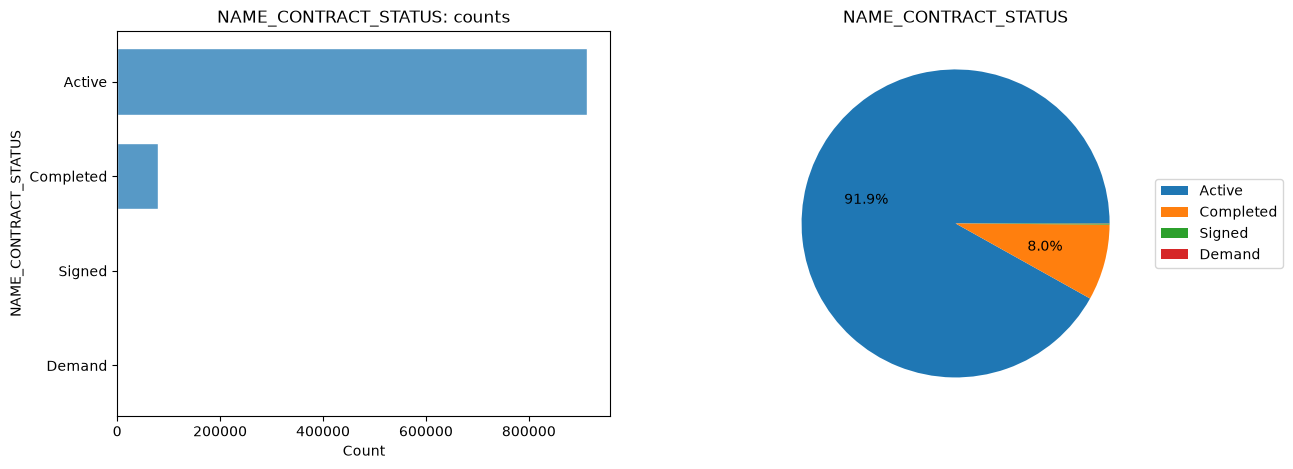

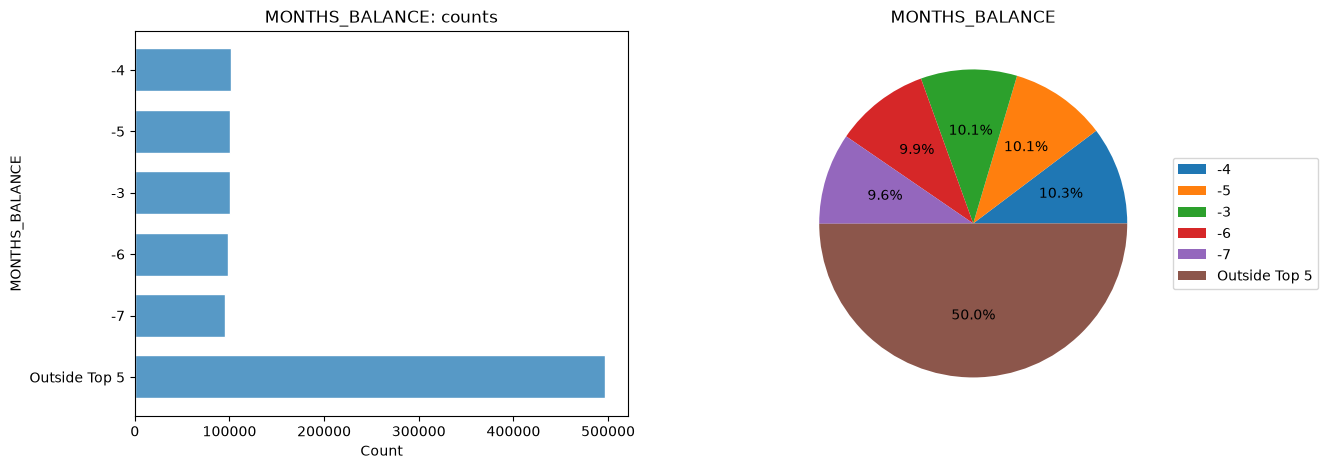

In [32]:
from univariate_analysis import boxplot_by_class, histogram_by_class, bar_chart, pie_chart

#numerical_columns = ["AMT_BALANCE"]
categorical_columns = ["NAME_CONTRACT_STATUS", "MONTHS_BALANCE"]

for cat_col in categorical_columns:
    fig, ax = plt.subplots(1, 2, figsize=(14,5))
    print("=" * 60)
    print(f"Value Counts of Category: {cat_col}")
    print(credit_df[cat_col].value_counts().head(5).to_string())
    print("=" * 60)
    print("\n")
    bar_chart(credit_df, cat_col, ax=ax[0], top_n= 5 )
    pie_chart(credit_df, cat_col, ax=ax[1], top_n= 5)
    

## Feature Engineering
1. Number of days a client paid DPD > 30 on a credit card. 
2. Utilisation Ratio of the most recent month. For this feature two things are at play - a high utilisation ratio should imply low personal liquidity (this is wrong actually, needs to be modified later). If the credit_card_limit of the most recent month is 0, fall back to the utilisation ratio of a previous month where a limit is non-trivial. See point 3 for further explanation.
3. Indicator, if there is a non-trivial balance with 0 limit within the past 12 months. Researching the dataset reveals that if a card is owed a balance and for some reason possibly due to not being able to pay, the credit card limit is set to 0 in the subsequent months. Intuitively this makes sense - a borrower that is unable to pay should not be extended more credit. 

In [11]:
# 1. Number of times each SK_ID_CURR was >30 days past due on a credit card.
num_dpd30 = (
    credit_df.groupby("SK_ID_CURR")["SK_DPD_DEF"]
    .apply(lambda s: (s > 30).sum())
    .rename("NUM_DPD_30")
)

# --- per (customer, month) utilisation, summed across cards before dividing so
# a small unused card can't dilute a maxed-out one. ---
monthly_totals = credit_df.groupby(["SK_ID_CURR", "MONTHS_BALANCE"])[
    ["AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL"]
].sum()

# # A 0 limit with a non-trivial balance most likely means the credit provider
# # shut off the limit for that month rather than the customer genuinely having
# # no credit line - NONTRIVIAL_BALANCE excludes residual-cents-level noise
# # (the smallest real observed balance under a 0 limit is ~4.5 cents).
# NONTRIVIAL_BALANCE = 1.0
# zero_limit_flagged = (
#     (monthly_totals["AMT_CREDIT_LIMIT_ACTUAL"] == 0)
#     & (monthly_totals["AMT_BALANCE"] > NONTRIVIAL_BALANCE)
# )

# # Utilisation is undefined wherever the limit was (apparently) shut off -
# # mask those months out so the backward-fill below can find the most recent
# # month that actually had a usable limit.
# usable_totals = monthly_totals[~zero_limit_flagged]
# monthly_utilisation = (
#     usable_totals["AMT_BALANCE"] / usable_totals["AMT_CREDIT_LIMIT_ACTUAL"]
# ).rename("utilisation")


# def latest_utilisation(group: pd.Series) -> float:
#     """Most recent month's utilisation for one customer, walking backward
#     over months where the limit was shut off (already excluded from `group`)
#     to the most recent month that still had a usable limit."""
#     if group.empty:
#         return np.nan
#     return group.sort_index(level="MONTHS_BALANCE", ascending=False).iloc[0]


# # 2. Latest-month (or most recent usable-limit month) credit utilisation ratio.
# credit_util_latest = (
#     monthly_utilisation.groupby("SK_ID_CURR").apply(latest_utilisation)
#     .rename("CREDIT_UTILISATION")
# )

# # 3. Flag: was the customer's latest month one where the limit looked shut
# # off despite a non-trivial balance still owed?
# latest_month_per_customer = credit_df.groupby("SK_ID_CURR")["MONTHS_BALANCE"].max()
# flag_zero_limit = (
#     zero_limit_flagged.groupby("SK_ID_CURR")
#     .apply(lambda s: bool(s.get((s.name, latest_month_per_customer[s.name]), False)))
#     .rename("FLAG_ZERO_LIMIT_NONZERO_BALANCE")
#     .astype(int)
# )

# credit_features = pd.concat(
#     [num_dpd30, credit_util_latest, flag_zero_limit], axis=1,
# )

# flag_zero_limit_ever = (
#     zero_limit_flagged.groupby("SK_ID_CURR").any()
#     .rename("FLAG_ZERO_LIMIT_NONZERO_BALANCE_EVER")
#     .astype(int)
# )

# credit_features["FLAG_ZERO_LIMIT_NONZERO_BALANCE_EVER"] = flag_zero_limit_ever
# credit_features.drop(["FLAG_ZERO_LIMIT_NONZERO_BALANCE"], axis=1, inplace=True)
# credit_features.head()

credit_features = pd.DataFrame(num_dpd30)

# Combination of DataFrames

In [12]:
application_train = pd.read_csv("home_credit/application_train.csv").iloc[:, :13]

# late_payment_features and credit_features are indexed by SK_ID_CURR (from
# their groupby) rather than having it as a column - merge needs it as a
# column on both sides, so bring it back with reset_index() first.
combined = (
    application_train
    .merge(late_payment_features.reset_index(), on="SK_ID_CURR", how="left")
    .merge(credit_features.reset_index(), on="SK_ID_CURR", how="left")
    .merge(bureau_features.reset_index(), on="SK_ID_CURR", how="left")
)

# A left join on application_train must never add or drop its rows - only
# left-side matches change, so row count/order is what to guard here.
assert len(combined) == len(application_train), "left join changed the row count"
assert combined["SK_ID_CURR"].equals(application_train["SK_ID_CURR"]), "left join reordered/changed rows"

combined.head()
columns_to_fill_0 = combined.columns[~combined.columns.isin(application_train.columns)]


combined[columns_to_fill_0] = combined[columns_to_fill_0].fillna(0)

In [30]:
from column_analysis import print_all_tables

print_all_tables(combined)


1. TYPE TABLE
                        dtype                inferred_type  n_unique  unique_ratio             example  memory_mb
column                                                                                                           
SK_ID_CURR              int64         identifier (numeric)    307511        1.0000              100002       2.35
TARGET                  int64                       binary         2        0.0000                   1       2.35
NAME_CONTRACT_TYPE        str                       binary         2        0.0000          Cash loans      17.44
CODE_GENDER               str                  categorical         3        0.0000                   M      14.66
FLAG_OWN_CAR              str                       binary         2        0.0000                   N      14.66
FLAG_OWN_REALTY           str                       binary         2        0.0000                   Y      14.66
CNT_CHILDREN            int64  categorical (integer-coded)        15     

In [31]:
late_payment_index = late_payment_features.index
credit_features_index = credit_features.index
bureau_util_index = bureau_util_features.index

train_index = application_train.SK_ID_CURR

print(f"Late Payment Overlap: {late_payment_index.isin(train_index).sum() / len(train_index): .4f}")
print(f"Credit Overlap: {credit_features_index.isin(train_index).sum() / len(train_index): .4f}")
print(f"Bureau Overlap: {bureau_util_index.isin(train_index).sum() / len(train_index): .4f}")

Late Payment Overlap:  0.7014
Credit Overlap:  0.2826
Bureau Overlap:  0.6600


The problem to immediately address is that the credit features have very poor overlap with the training set, so it can't possibly provide that much meaningful information.

In [21]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(combined, test_size=0.2, random_state=42, stratify=combined["TARGET"])

## Mising Value Analysis

We need to determine the nature of the missing values - whether the missing values occur randomly or there is some pattern within the missing values.

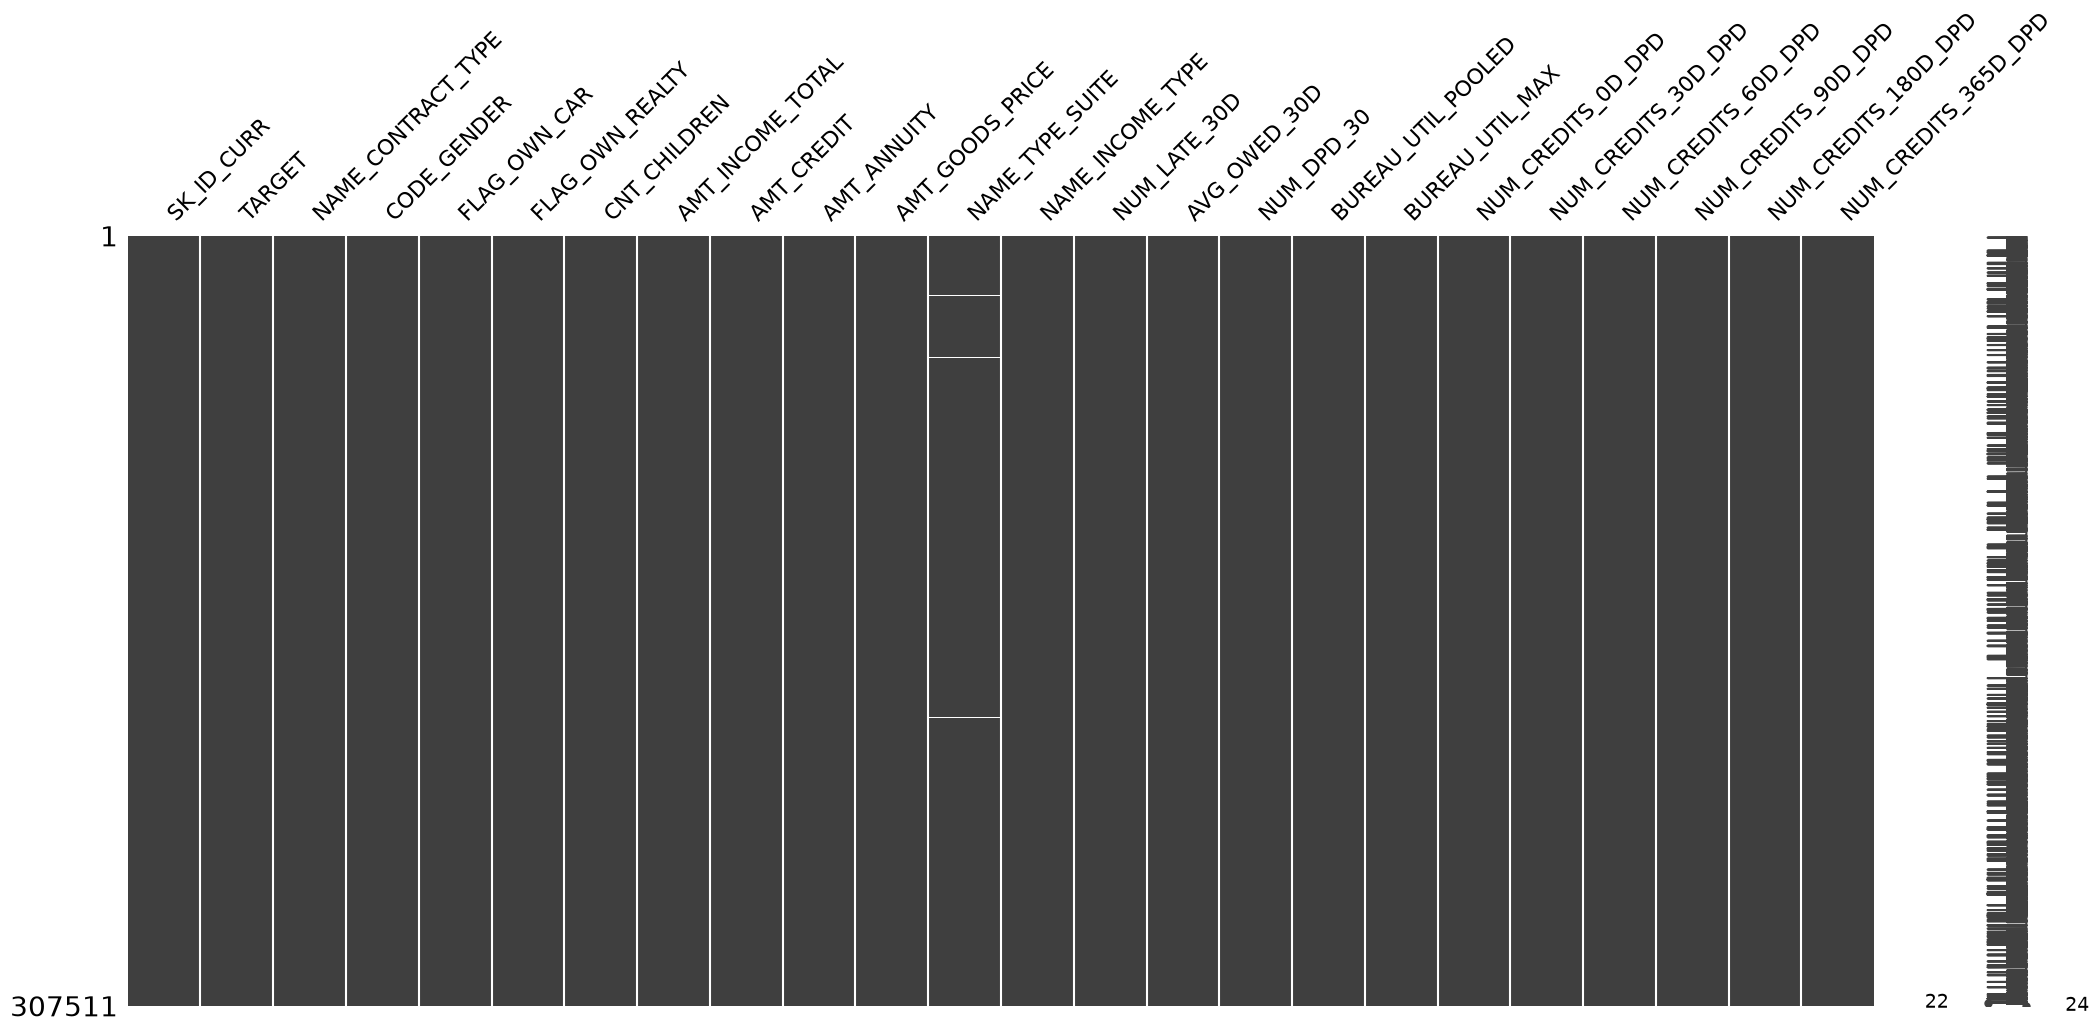

In [33]:
import missingno as msno

plot = msno.matrix(combined)
plt.show()

From the missingno plot it appears to be that `NAME_TYPE_SUITE` is disappearing randomly (this is of course, an __Assumption__). 

We want to avoid dropping columns with `TARGET` == 1, so we will investigate the missing rows together with `TARGET` == 1.

In [35]:
na_values = combined.isna().any(axis=1)
target_one = combined['TARGET'] == 1

print("Number of missing 1 values: ", len(combined[target_one & na_values]), "Number of 1 values: ", len(combined[target_one])) 

Number of missing 1 values:  70 Number of 1 values:  24825


There is a non-trivial number of missing 1 values within the training set. A missing value imputation strategy should be chosen. A very simple strategy is to impute the numerical columns with the median and the categorical columns with their own "Missing" category.

In [22]:
from sklearn.model_selection import train_test_split

numerical_missing = ["AMT_GOODS_PRICE", "AMT_ANNUITY"]
categorical_missing = ["NAME_TYPE_SUITE"]

for num_col in numerical_missing:
    training_median = train_df[num_col].median()
    train_df[num_col] = train_df[num_col].fillna(training_median)
    val_df[num_col] = val_df[num_col].fillna(training_median)

for cat_col in categorical_missing:
    train_df[cat_col] = train_df[cat_col].fillna("Missing")
    val_df[cat_col] = val_df[cat_col].fillna("Missing")

## Exploratory Data Analysis for the Training Set 

In [37]:
from column_analysis import infer_semantic_type

numerical_cols = [
    col for col in train_df.columns
    if col not in ("SK_ID_CURR", "TARGET")
    and infer_semantic_type(train_df[col]) in ("numeric (continuous)", "numeric (discrete)")
]

categorical_cols = [
    col for col in train_df.columns 
    if col not in ("SK_ID_CURR", "TARGET") 
    and infer_semantic_type(train_df[col]) in ("binary", "categorical", "categorical (integer-coded)")]

c:\Users\trund\Finance_Data_Science\credit_risk\univariate_analysis.py:195: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=plot_df, y=cat_col, ax=ax, **kwargs)


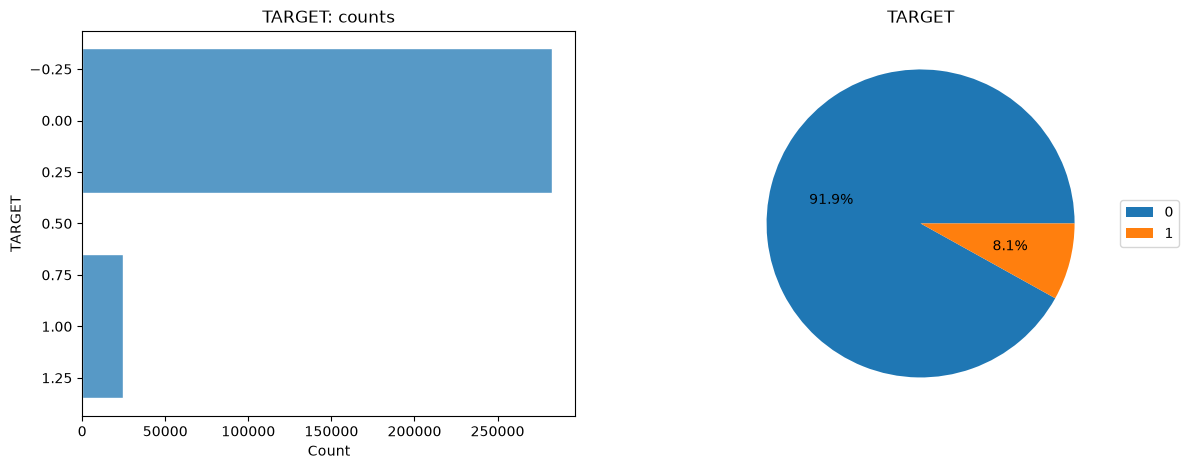

In [38]:
from univariate_analysis import _binary_classes, bar_chart, pie_chart
from palette import CATEGORICAL_PALETTE

majority_class, minority_class = _binary_classes(train_df, "TARGET")
palette = {majority_class: CATEGORICAL_PALETTE[0], minority_class: CATEGORICAL_PALETTE[1]}

fig, ax = plt.subplots(1, 2, figsize=(14,5))
bar_chart(combined, "TARGET", ax=ax[0], top_n = 2, palette= palette)
pie_chart(combined, "TARGET", ax=ax[1], top_n = 2,  autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",)

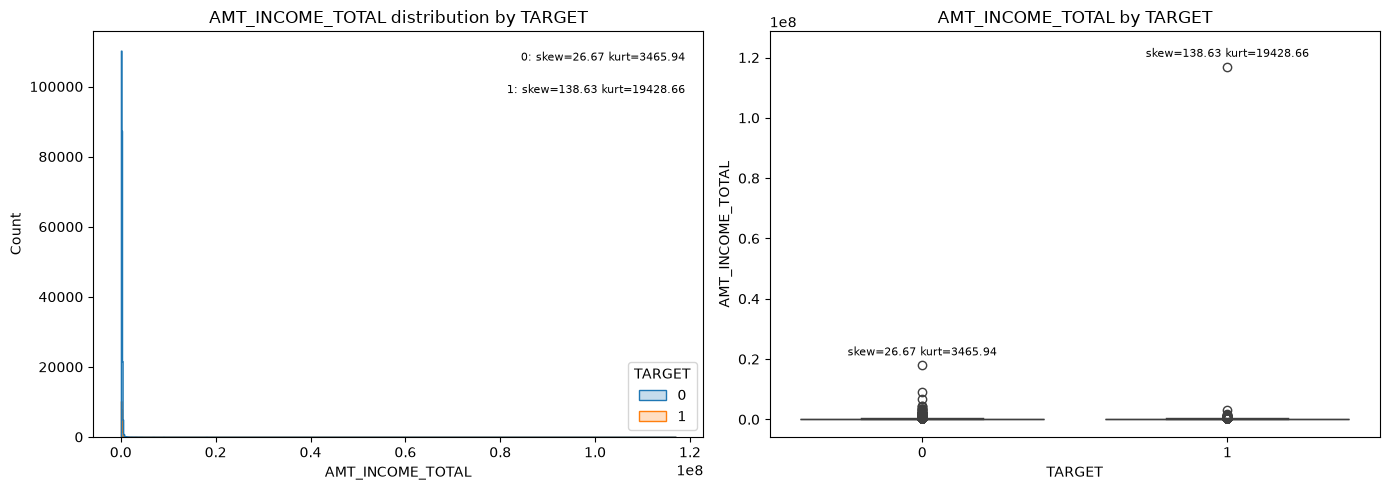

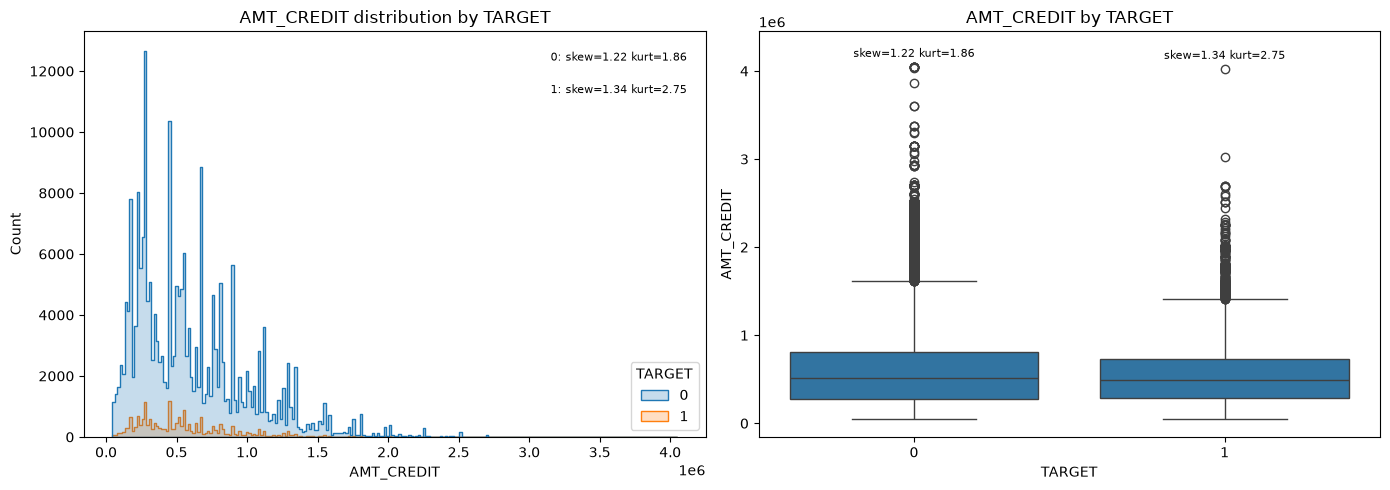

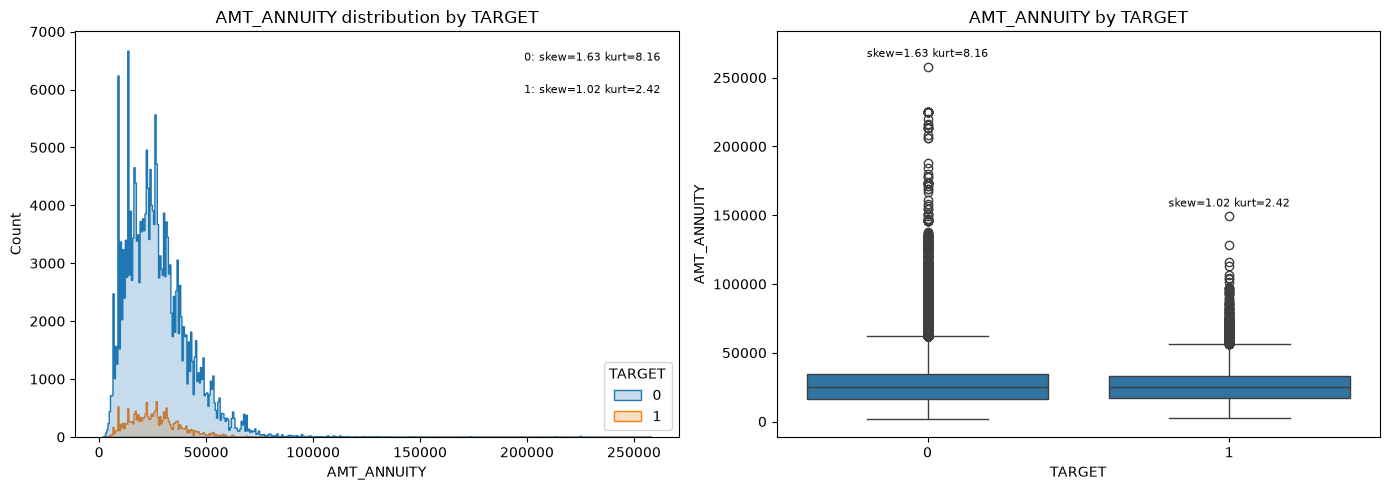

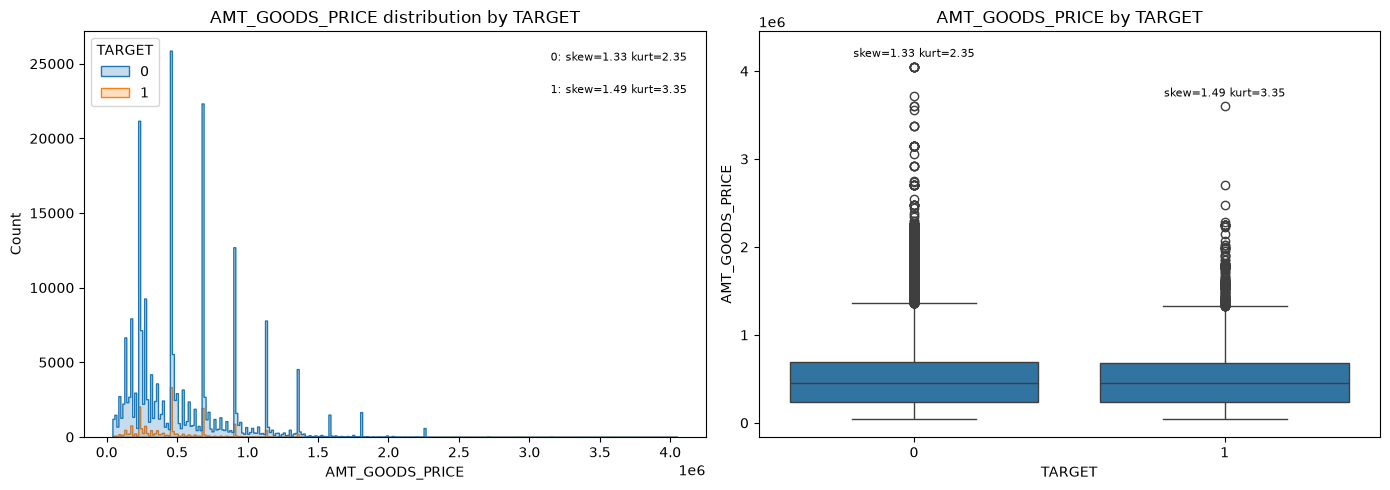

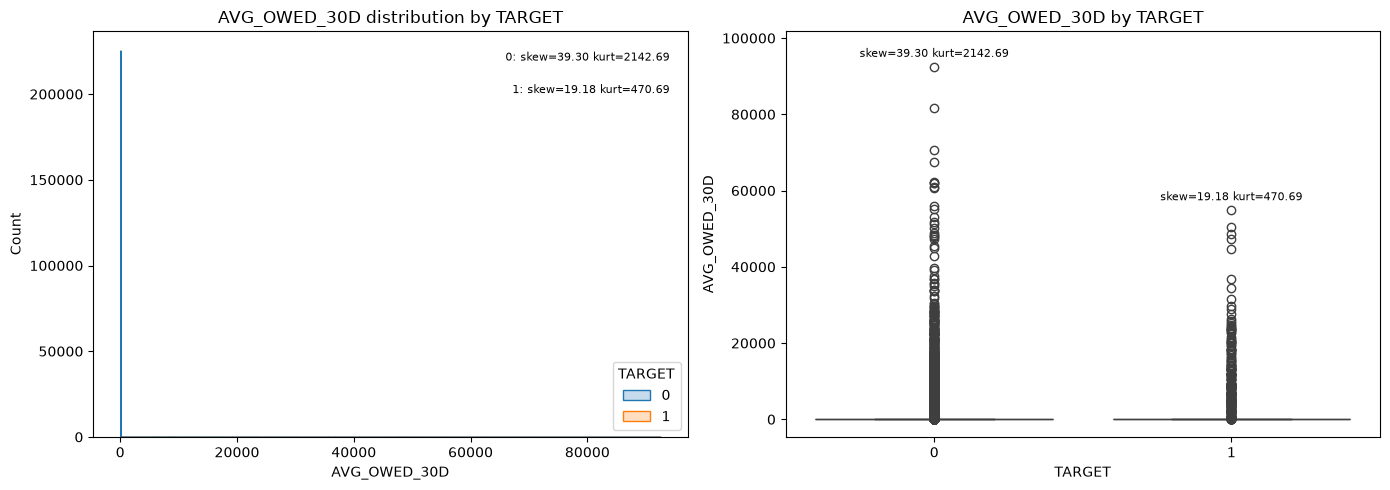

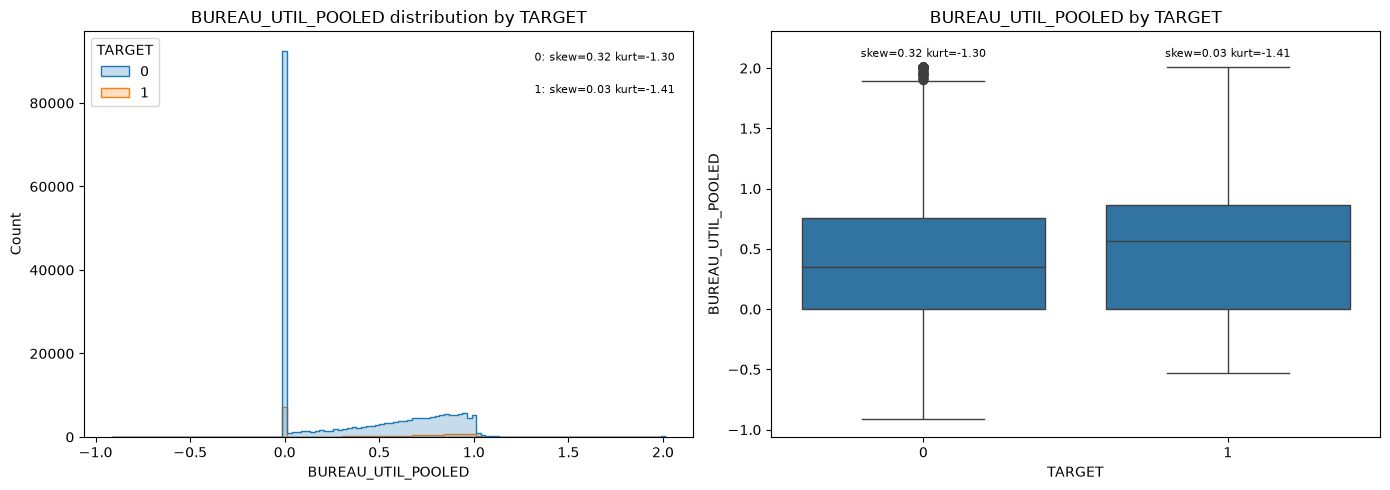

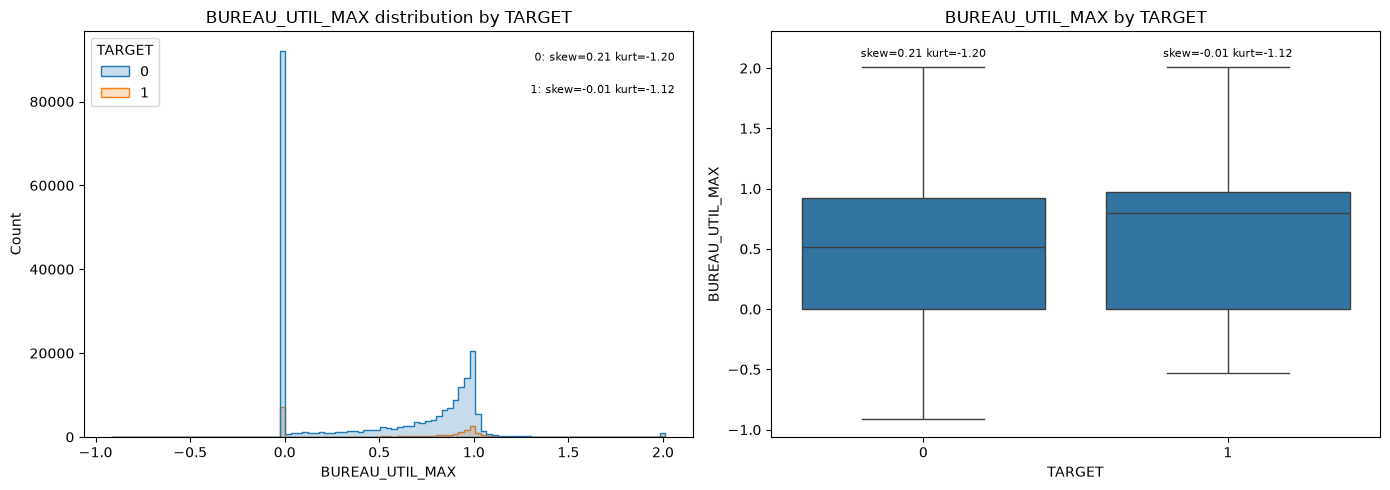

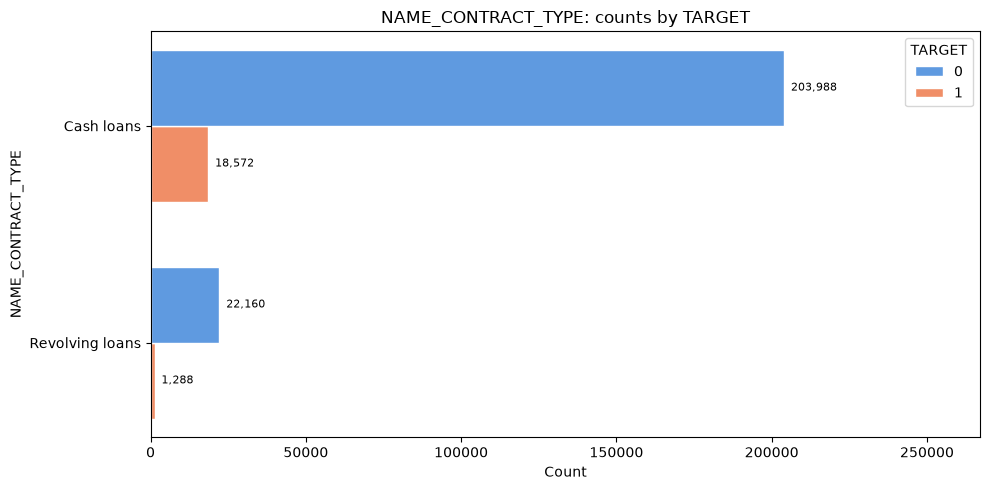

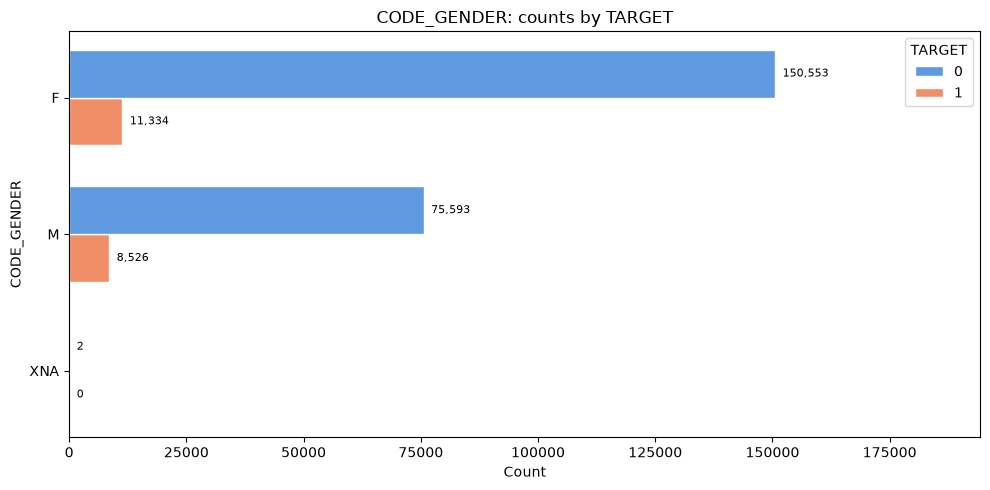

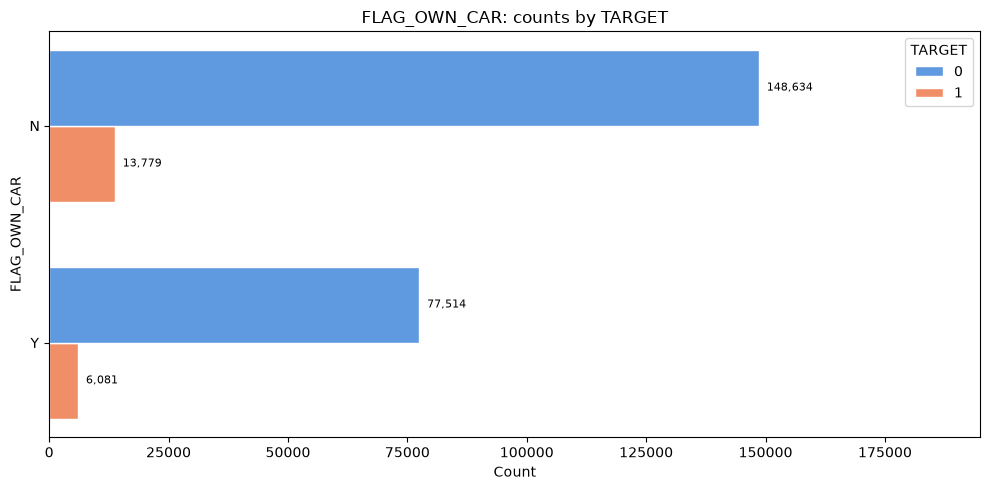

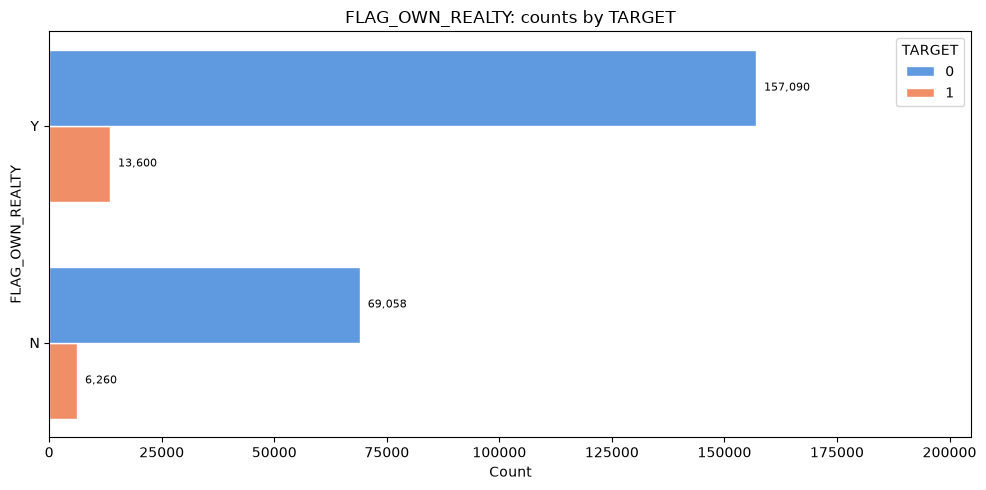

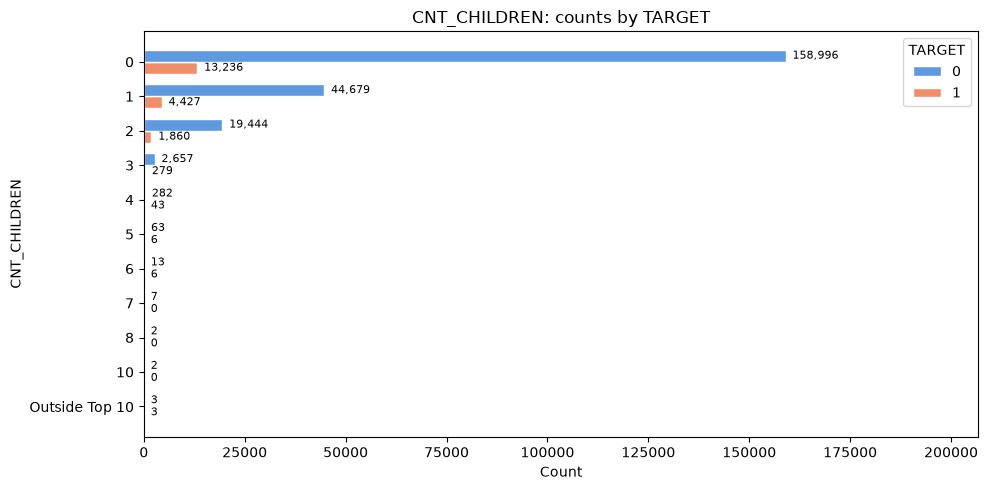

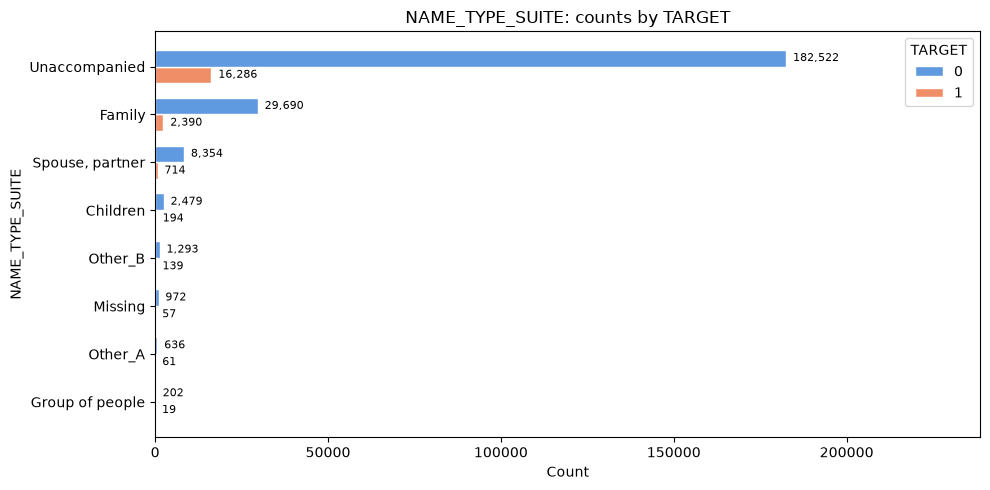

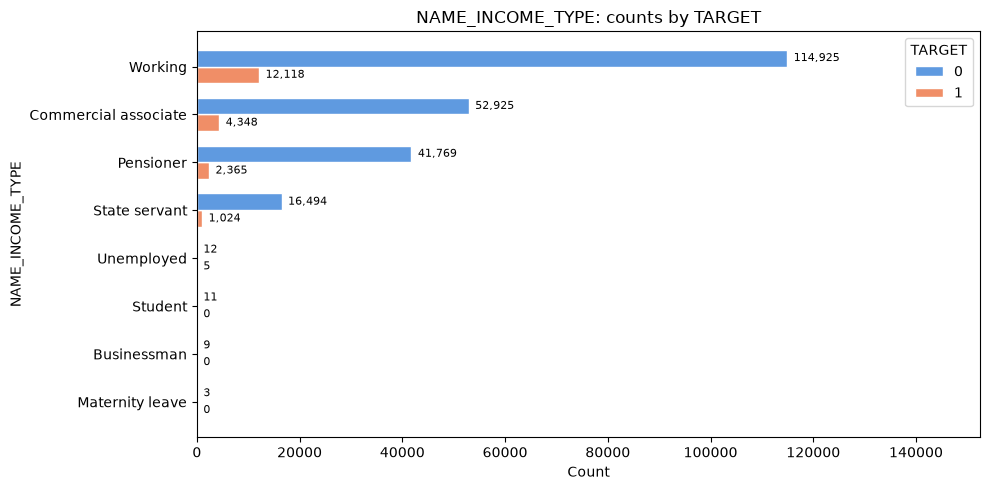

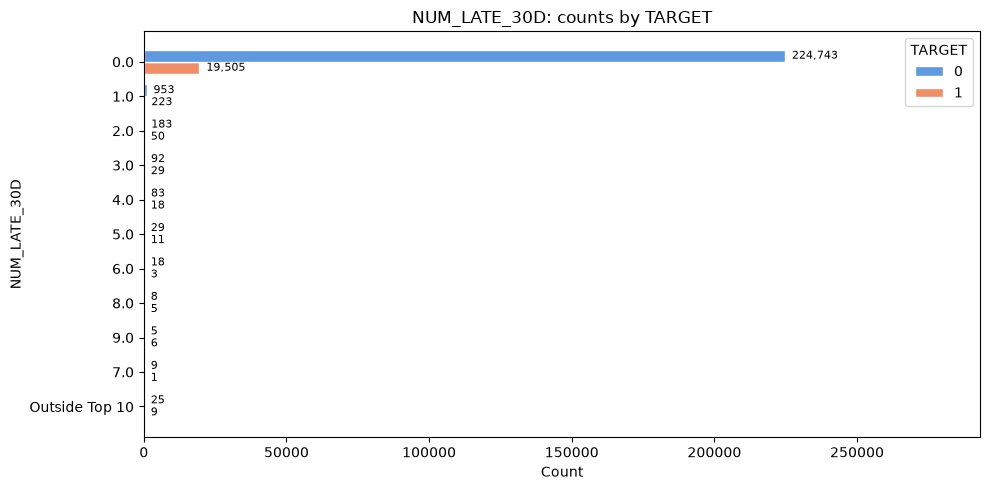

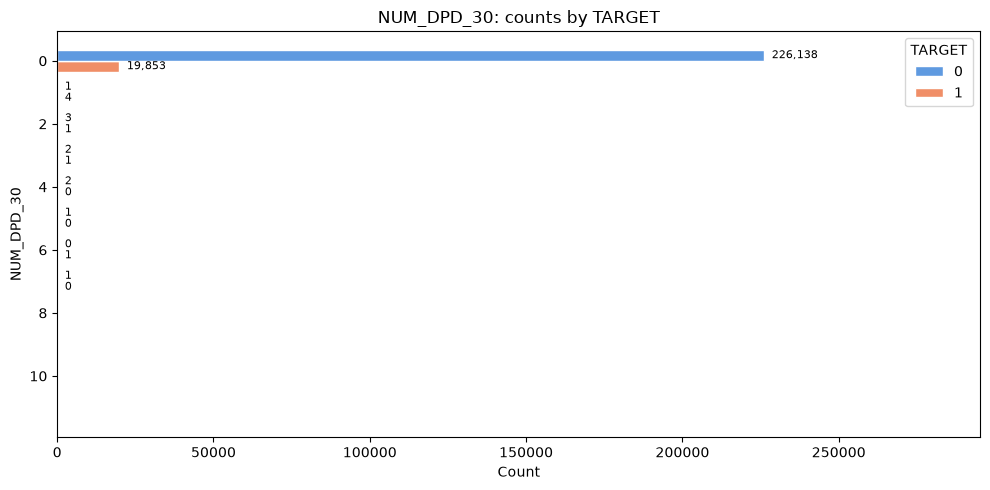

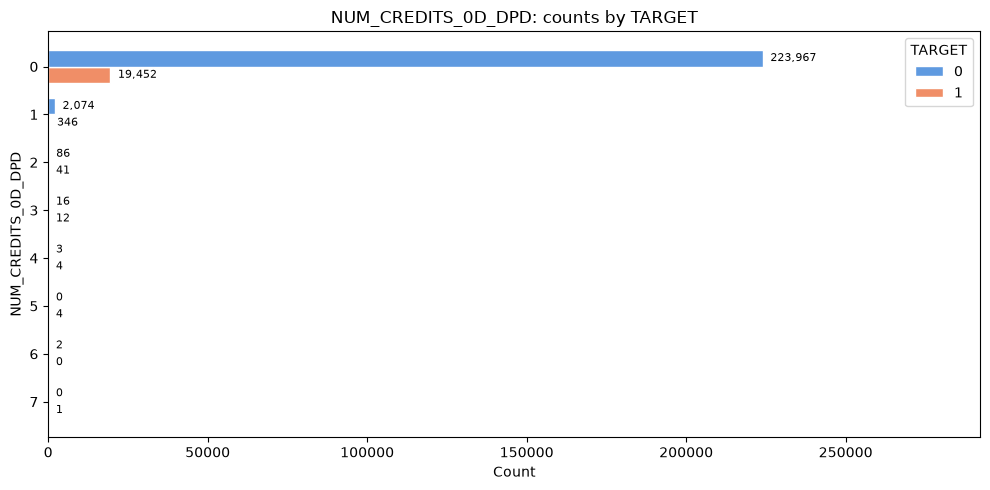

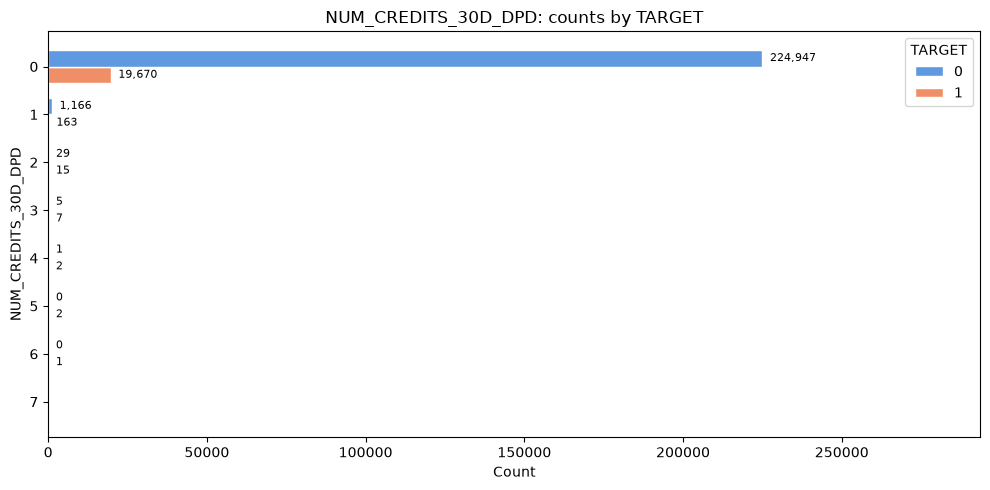

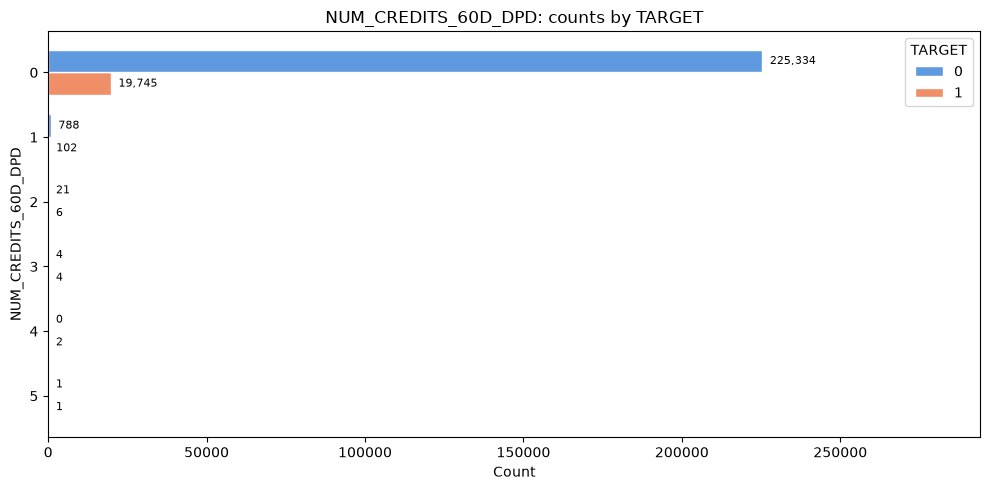

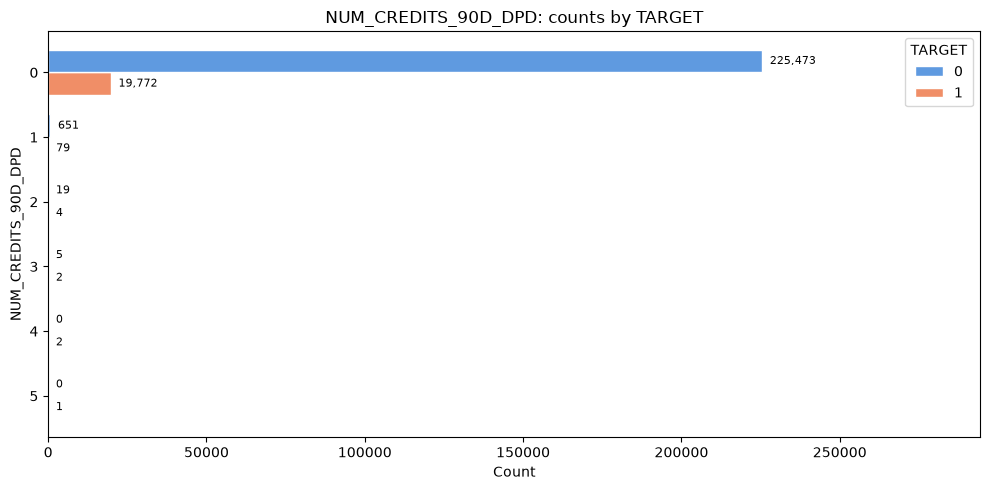

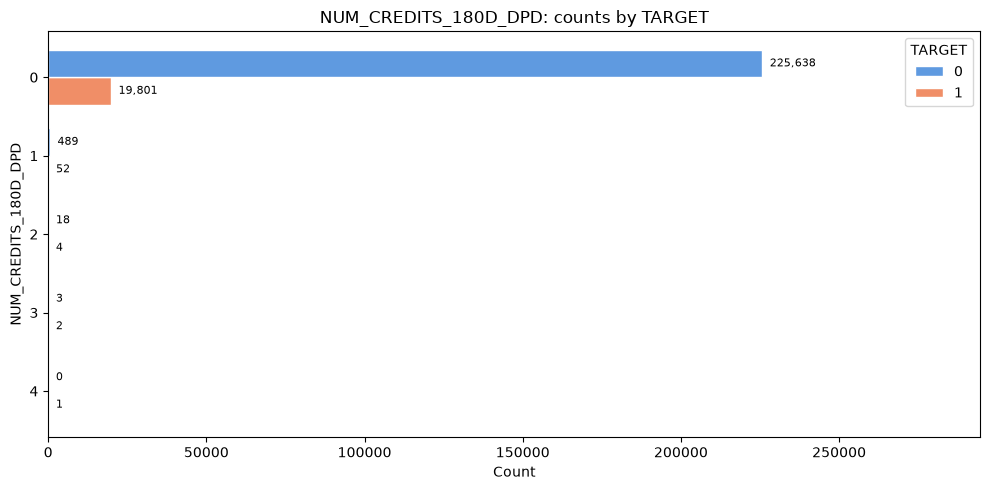

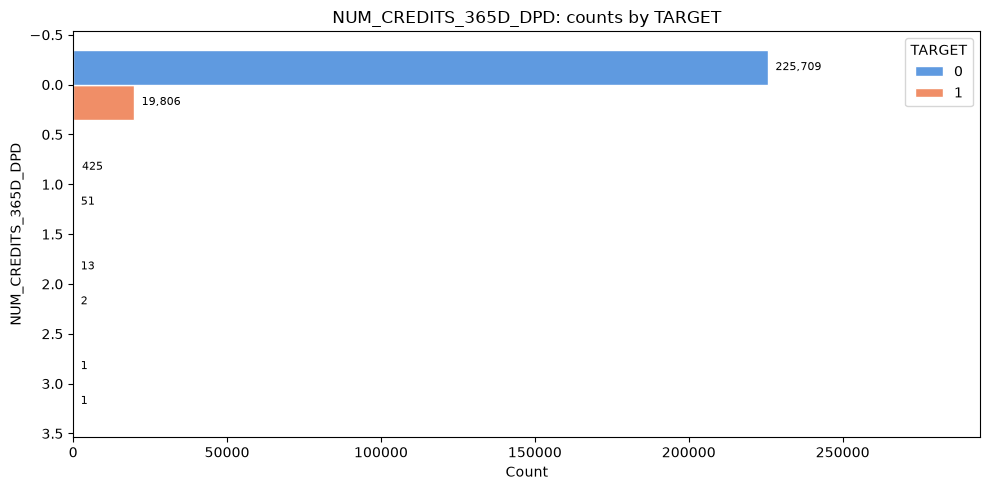

In [39]:
from univariate_analysis import _binary_classes, histogram_by_class, boxplot_by_class, bar_chart
from palette import CATEGORICAL_PALETTE

majority_class, minority_class = _binary_classes(train_df, "TARGET")
palette = {majority_class: CATEGORICAL_PALETTE[0], minority_class: CATEGORICAL_PALETTE[1]}

# --- numerical columns: histogram + boxplot, split by TARGET ---
for num_col in numerical_cols:
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    histogram_by_class(train_df, num_col, ax=ax[0], target_col="TARGET")
    boxplot_by_class(train_df, num_col, ax=ax[1], target_col="TARGET")
    plt.tight_layout()
    plt.show()

# --- categorical columns: bar chart, split by TARGET ---
for cat_col in categorical_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    bar_chart(train_df, cat_col, ax=ax, target_col="TARGET", top_n=10, palette=palette)
    plt.tight_layout()
    plt.show()

The most glaring thing is that the composition of defaulters has a clear bias towards Cash Loans in the `TYPE` column. There should be another variable that helps us predict this together with that. Furthermore, from the plots there is also a need to winsorise multiple columns to see the distribution better, but this is to be done later. 

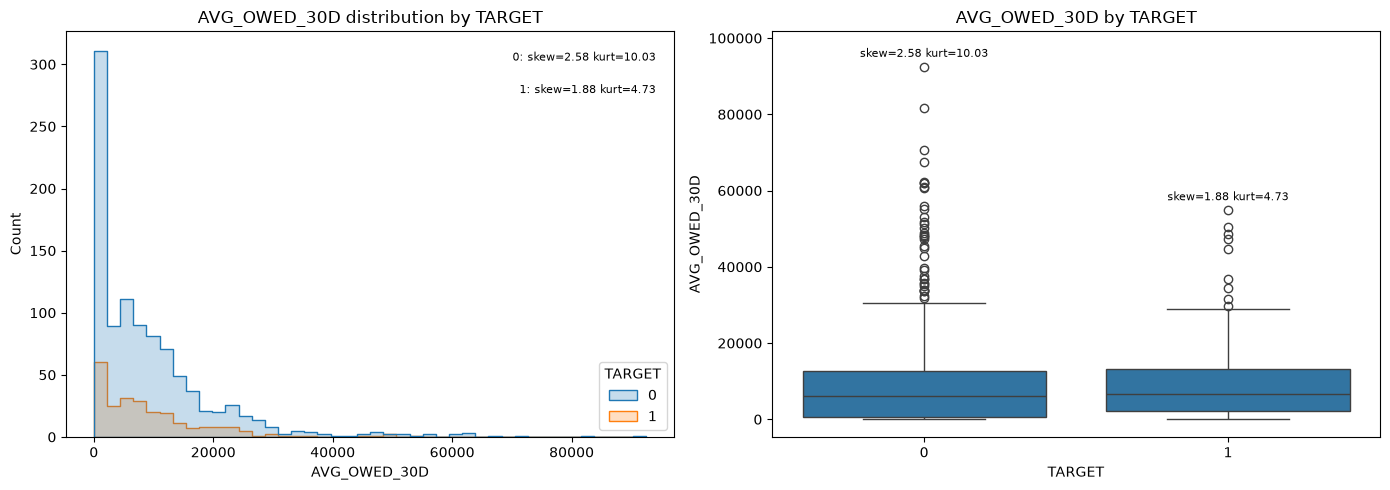

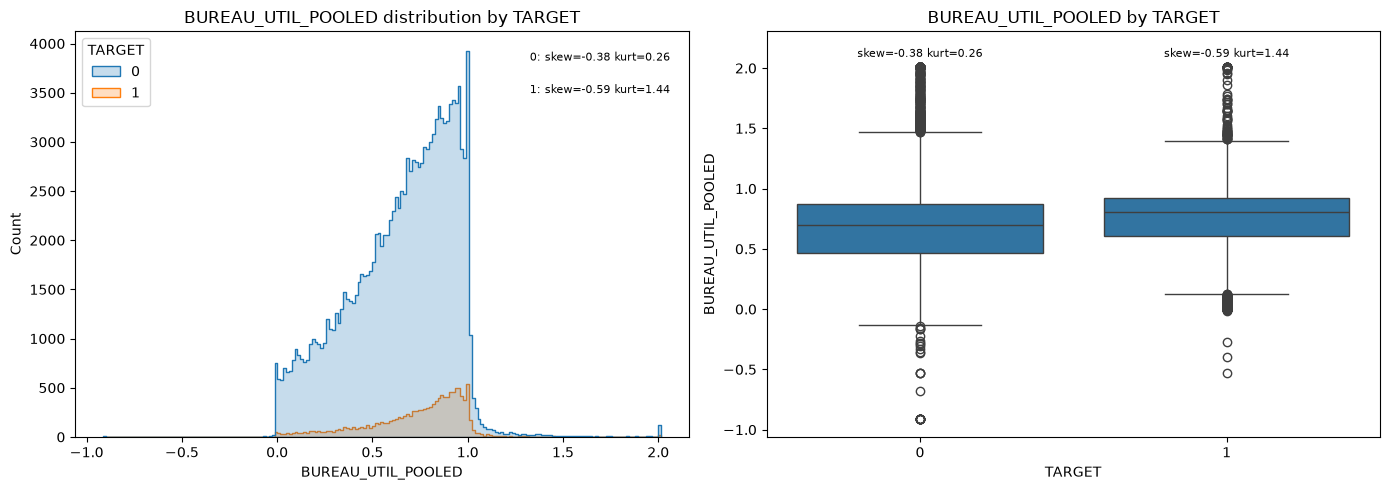

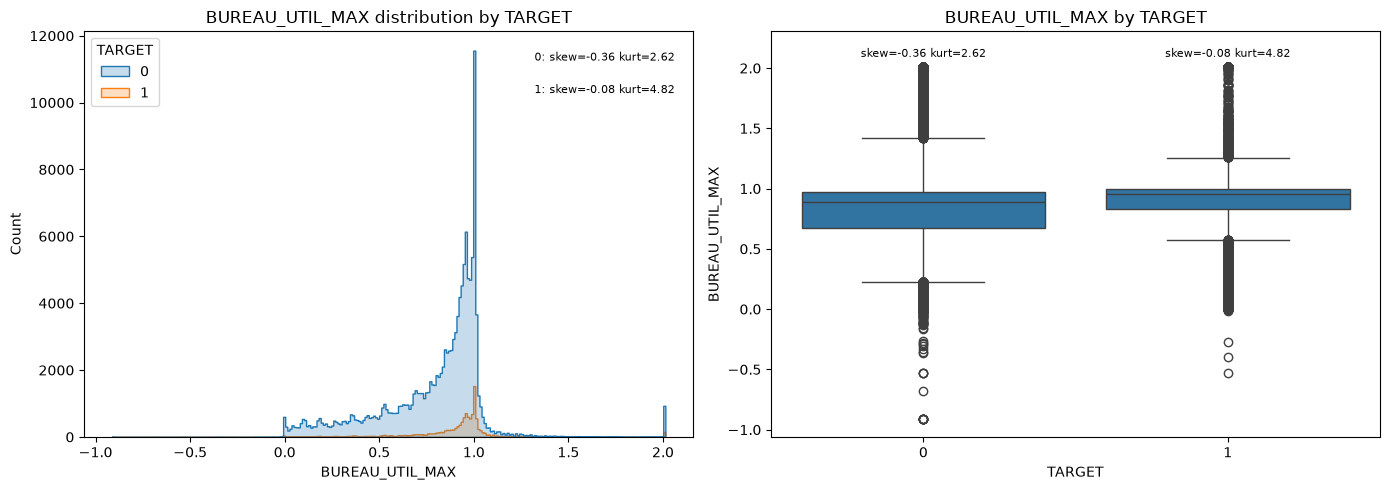

In [40]:
engineered_columns = ["AVG_OWED_30D", "BUREAU_UTIL_POOLED", "BUREAU_UTIL_MAX"]

# Both columns are 0 for the (large) majority of customers who were never
# late/never carried a card balance in the window - including those zeros
# would swamp the histogram/boxplot and hide the shape of the distribution
# for customers where the feature actually has a value.

for eng_col in engineered_columns:
    nonzero_df = train_df[train_df[eng_col] != 0]

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    histogram_by_class(nonzero_df, eng_col, ax=ax[0], target_col="TARGET")
    boxplot_by_class(nonzero_df, eng_col, ax=ax[1], target_col="TARGET")
    plt.tight_layout()
    plt.show()

It is somewhat surprising from these columns that the average amount owed past the 30 days on its own provide no information about Class 1. 

## Correlation Analysis

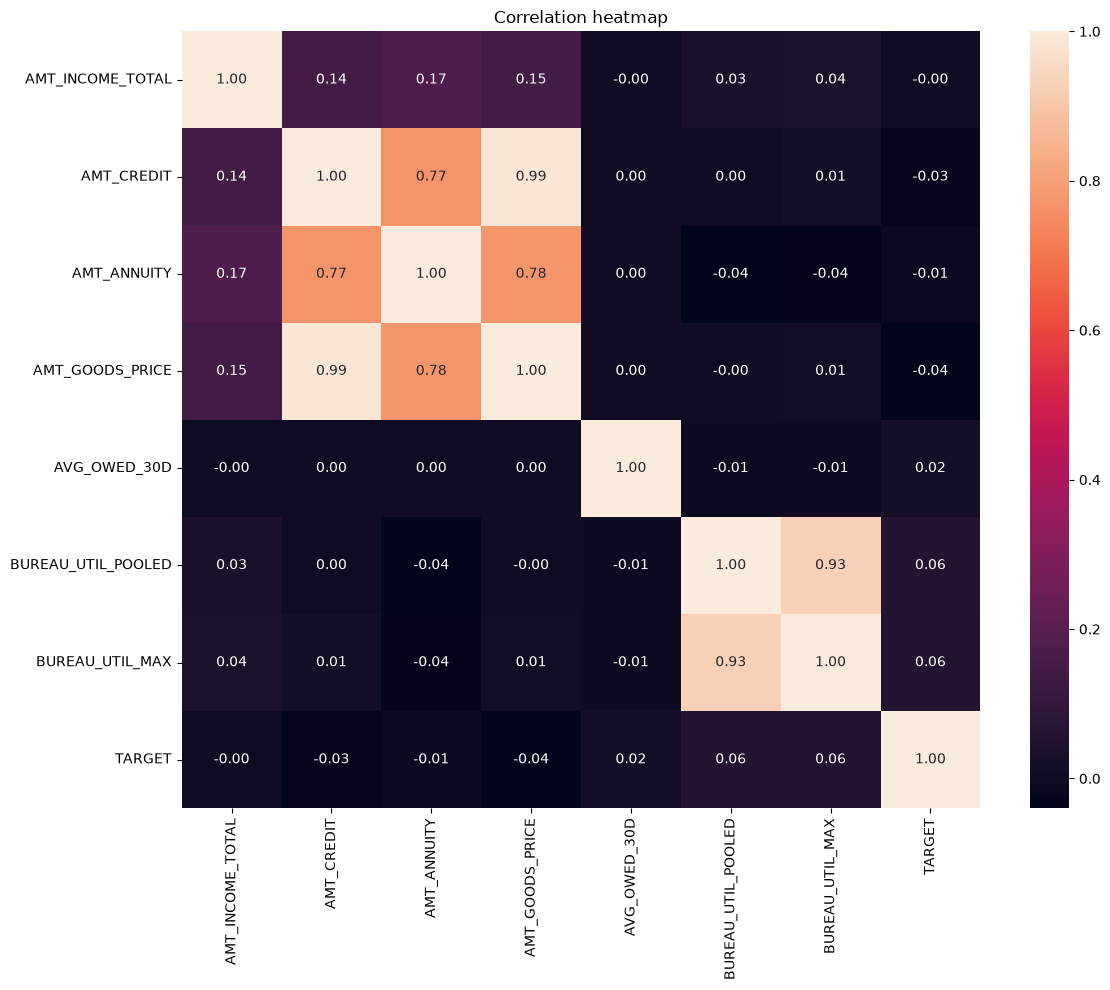

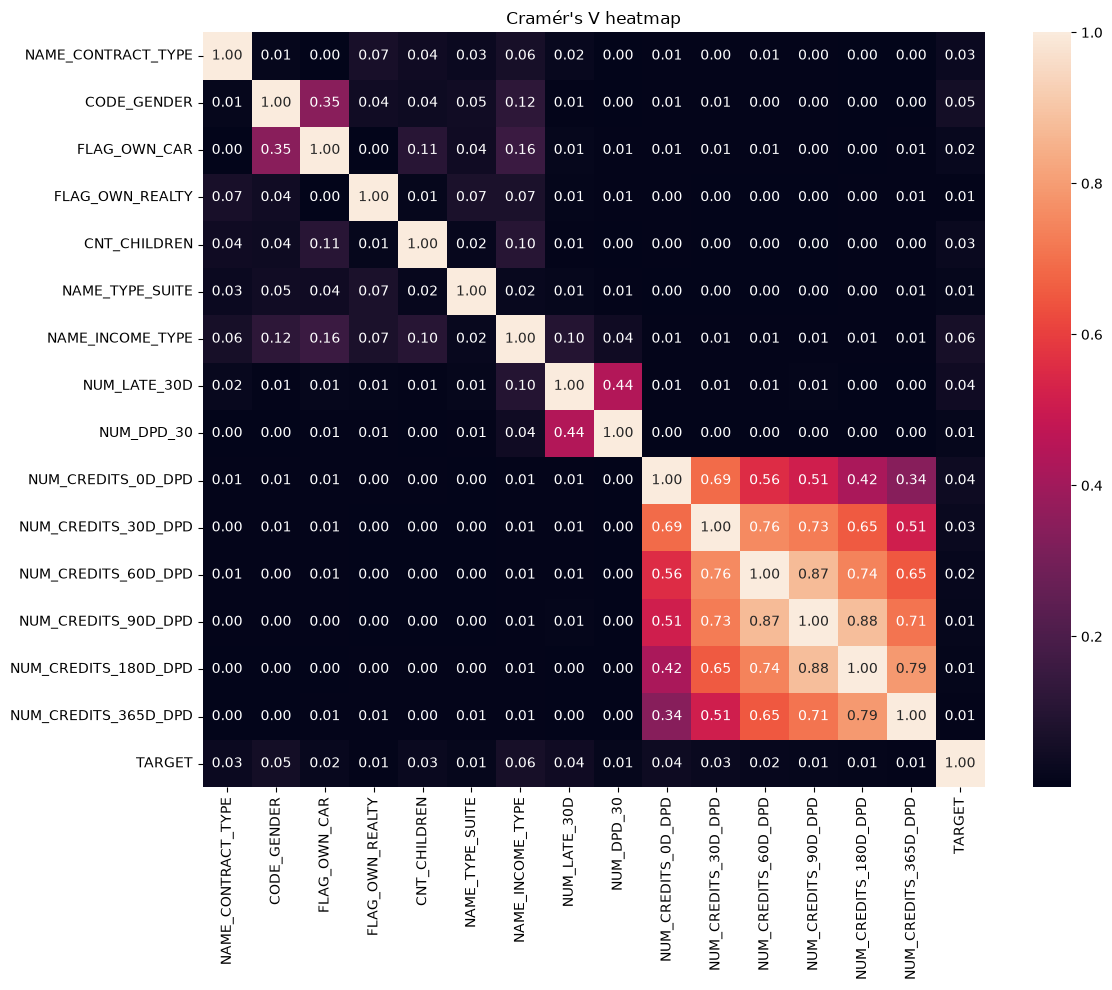

In [41]:
from correlations import correlation_heatmap, cramers_v_heatmap

# TARGET was excluded from numerical_cols/categorical_cols earlier (it's the
# label, not a feature) - added back explicitly here so both heatmaps also
# show each column's association with it, alongside the feature-feature
# associations.

# 1. Linear (Pearson) correlation of numerical columns with each other and TARGET.
fig, ax = plt.subplots(figsize=(12, 10))
correlation_heatmap(train_df[numerical_cols + ["TARGET"]], ax=ax, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

# 2. Cramer's V association of categorical columns with each other and TARGET.
# Cramer's V needs categorical inputs - TARGET (0/1) is cast to string so
# _cramers_v's pd.crosstab treats it as a category rather than a number.
fig, ax = plt.subplots(figsize=(12, 10))
cramers_v_heatmap(
    train_df[categorical_cols].assign(TARGET=train_df["TARGET"].astype(str)),
    ax=ax, annot=True, fmt=".2f",
)
plt.tight_layout()
plt.show()

From an earlier analysis - we wished to test which column in bureau credits had the greatest correlation with the target variable. From the analysis its clear that this column is the 0D DPD column. Hence we will drop all other num_credits_0D column. 

In [24]:
columns_to_drop = ["NUM_CREDITS_30D_DPD", "NUM_CREDITS_60D_DPD", "NUM_CREDITS_90D_DPD", "NUM_CREDITS_180D_DPD", "NUM_CREDITS_365D_DPD"]

train_df = train_df.drop(columns_to_drop, axis=1)
val_df = val_df.drop(columns_to_drop, axis=1)

## Saving for Logistic Regression

In [25]:
from pathlib import Path

OUTPUT_DIR = Path("home_credit") / "processed" / "bureau"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_path = OUTPUT_DIR / "train_df.csv"
val_path = OUTPUT_DIR / "val_df.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)

print(f"Wrote {train_path} ({train_df.shape[0]:,} rows)")
print(f"Wrote {val_path} ({val_df.shape[0]:,} rows)")

Wrote home_credit\processed\bureau\train_df.csv (246,008 rows)
Wrote home_credit\processed\bureau\val_df.csv (61,503 rows)
